In [15]:
import pandas as pd
import numpy as np
import os
import sys
import gzip
from tqdm.notebook import tqdm
import gc
import pysam
import re
pd.set_option('display.max_columns', None)
import seaborn as sns
import matplotlib.pyplot as plt
import collections

In [16]:
gencodeRM = pd.read_csv(
    #"/project/mkonkel/tangeno/users/giannim/chrY/exonRepeatmasker/DAZ/DAZrepeatOut_v2/gencode/DAZ_mergedReads.fa.out",
    "/project/mkonkel/tangeno/users/giannim/chrY/exonRepeatmasker/DAZ/DAZrepeatOut_v3/gencode/DAZ_mergedReads.fa.out",
    sep=r'\s+',
    skiprows=3,
    header=None,
    names=range(16),       # allocate 16 columns so no line is "too wide"
    engine='python'
)
gencodeRM

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,828,24.6,0.5,2.9,SRR31360662.10047102,12,220,(1189),+,DAZ1_EXON29,Unspecified,7,210,(2105),1,None
1,736,18.8,0.6,6.0,SRR31360662.10047102,212,386,(1023),C,DAZ1_EXON29,Unspecified,(2149),166,1,2,*
2,16,9.3,0.0,0.0,SRR31360662.10047102,390,412,(997),+,(A)n,Simple_repeat,1,23,(0),3,None
3,925,0.0,0.0,0.0,SRR31360662.10047102,513,611,(798),C,DAZ1_EXON27,Unspecified,(0),99,1,4,None
4,1241,20.4,2.1,1.8,SRR31360662.10047102,750,1028,(381),C,DAZ1_EXON29,Unspecified,(2035),280,1,5,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5390,665,0.0,0.0,0.0,SRR31360662.9980017,808,879,(1267),+,DAZ1_EXON24,Unspecified,1,72,(0),5391,None
5391,669,0.0,0.0,0.0,SRR31360662.9980017,880,951,(1195),+,DAZ1_EXON25,Unspecified,1,72,(0),5392,None
5392,309,0.0,0.0,0.0,SRR31360662.9980017,952,986,(1160),+,DAZ1_EXON26,Unspecified,1,35,(0),5393,None
5393,925,0.0,0.0,0.0,SRR31360662.9980017,987,1085,(1061),+,DAZ1_EXON27,Unspecified,1,99,(0),5394,None


In [17]:
pooledRM = pd.read_csv("/project/mkonkel/tangeno/users/giannim/chrY/exonRepeatmasker/DAZ/DAZrepeatOut_v3/pooledTestis/DAZ_mergedReads.fa.out", sep=r'\s+', skiprows=3, header=None)
pooledRM

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,309,0.0,0.0,0.0,SRR12544672.130521,272,306,(1834),C,DAZ1_EXON26,Unspecified,(0),35,1,1
1,631,0.0,1.4,0.0,SRR12544672.130521,307,377,(1763),C,DAZ1_EXON25,Unspecified,(0),72,1,2
2,638,0.0,0.0,1.4,SRR12544672.130521,378,450,(1690),C,DAZ1_EXON23,Unspecified,(0),72,1,3
3,657,0.0,0.0,0.0,SRR12544672.130521,451,522,(1618),C,DAZ1_EXON20-22,Unspecified,(0),72,1,4
4,668,0.0,0.0,0.0,SRR12544672.130521,523,594,(1546),C,DAZ1_EXON23,Unspecified,(0),72,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
349,591,0.0,0.0,0.0,SRR12544673.93059,3134,3197,(503),C,DAZ1_EXON5-10-15,Unspecified,(0),64,1,350
350,461,0.0,0.0,0.0,SRR12544673.93059,3198,3249,(451),C,DAZ1_EXON4-9-14,Unspecified,(0),52,1,351
351,830,0.0,0.0,0.0,SRR12544673.93059,3250,3341,(359),C,DAZ1_EXON3-8-13,Unspecified,(0),92,1,352
352,1382,0.0,0.0,0.0,SRR12544673.93059,3342,3488,(212),C,DAZ1_EXON2-7-12,Unspecified,(0),147,1,353


In [4]:
letterExonDict={'17':'B', '18':'C','19':'D','20-22':'E','21':'F','23':'X','24':'Y','25':'Z'}

# Previous iterations - ignore

In [22]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import pandas as pd

def plot_repeatmasker_reads(df, exon_col=9, read_col=4, figsize_scale=1.0):
    df = df.copy()
    df['exon_num'] = (
        df.iloc[:, exon_col]
          .astype(str)
          .str.split('EXON')
          .str[-1]
          .str.strip()
    )
    reads    = df.iloc[:, read_col].unique()
    exon_ids = list(dict.fromkeys(df['exon_num']))  # ← preserve file order, no sorting
    exon_pos = {e: i for i, e in enumerate(exon_ids)}
    n_reads  = len(reads)
    n_exons  = len(exon_ids)

    box_w, box_h = 0.6, 0.4
    fig_w = max(10, n_exons * 1.2) * figsize_scale
    fig_h = max(4,  n_reads * 0.8) * figsize_scale
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    cmap   = plt.get_cmap('tab10')
    colors = {r: cmap(i % 10) for i, r in enumerate(reads)}

    for row_idx, read in enumerate(reads):
        sub   = df[df.iloc[:, read_col] == read]
        exons = sub['exon_num'].unique()
        xs    = sorted([exon_pos[e] for e in exons])
        y     = row_idx

        if len(xs) > 1:
            ax.plot([xs[0] + box_w / 2, xs[-1] + box_w / 2],
                    [y, y], color=colors[read], lw=1.5, zorder=1)

        for e in exons:
            x = exon_pos[e]
            rect = mpatches.FancyBboxPatch(
                (x - box_w / 2, y - box_h / 2), box_w, box_h,
                boxstyle="round,pad=0.05",
                facecolor=colors[read], edgecolor='white',
                linewidth=0.8, zorder=2
            )
            ax.add_patch(rect)
            ax.text(x, y, e, ha='center', va='center',
                    fontsize=7, fontweight='bold', color='white', zorder=3)

        ax.text(-0.6, y, read, ha='right', va='center', fontsize=8)

    ax.set_xlim(-1, n_exons)
    ax.set_ylim(-0.8, n_reads - 0.2)
    ax.set_xticks(range(n_exons))
    ax.set_xticklabels([f'Exon {e}' for e in exon_ids], rotation=45, ha='right', fontsize=8)
    ax.set_yticks([])
    ax.set_xlabel('Exon', fontsize=10)
    ax.set_title('RepeatMasker Read–Exon Map', fontsize=12, fontweight='bold')
    ax.spines[['left', 'right', 'top']].set_visible(False)
    plt.tight_layout()
    return fig, ax

In [21]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import pandas as pd

def plot_repeatmasker_reads(df, exon_col=9, read_col=4, figsize_scale=1.0):
    df = df.copy()
    df['exon_num'] = (
        df.iloc[:, exon_col]
          .astype(str)
          .str.split('EXON')
          .str[-1]
          .str.strip()
    )

    reads   = list(dict.fromkeys(df.iloc[:, read_col]))  # preserve file order, reads are still unique
    n_reads = len(reads)

    box_w, box_h = 0.6, 0.4
    max_exons = max(len(df[df.iloc[:, read_col] == r]) for r in reads)

    fig_w = max(10, max_exons * 1.2) * figsize_scale
    fig_h = max(4,  n_reads  * 0.8) * figsize_scale
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    cmap   = plt.get_cmap('tab10')
    colors = {r: cmap(i % 10) for i, r in enumerate(reads)}

    for row_idx, read in enumerate(reads):
        sub = df[df.iloc[:, read_col] == read]

        # All rows for this read, duplicates included, in file order
        exons = list(sub['exon_num'])
        y = row_idx
        xs = list(range(len(exons)))

        # Connecting line
        if len(xs) > 1:
            ax.plot([xs[0] + box_w / 2, xs[-1] + box_w / 2],
                    [y, y], color=colors[read], lw=1.5, zorder=1)

        # Exon rectangles with labels
        for x, e in zip(xs, exons):
            rect = mpatches.FancyBboxPatch(
                (x - box_w / 2, y - box_h / 2), box_w, box_h,
                boxstyle="round,pad=0.05",
                facecolor=colors[read], edgecolor='white',
                linewidth=0.8, zorder=2
            )
            ax.add_patch(rect)
            ax.text(x, y, e, ha='center', va='center',
                    fontsize=7, fontweight='bold', color='white', zorder=3)

        # Read name label on left
        ax.text(-0.6, y, read, ha='right', va='center', fontsize=8)

    ax.set_xlim(-1, max_exons)
    ax.set_ylim(-0.8, n_reads - 0.2)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines[['left', 'right', 'top', 'bottom']].set_visible(False)
    ax.set_title('RepeatMasker Read–Exon Map', fontsize=12, fontweight='bold')
    plt.tight_layout()
    return fig, ax

In [27]:
def get_exon_sort_key(exon_str):
    """Return the numeric value to use for orientation comparison, or None if not numeric."""
    try:
        return int(exon_str.split('-')[0])
    except ValueError:
        return None

def infer_orientation(exons):
    """
    Return True if read should be flipped (descending order).
    Prefers comparing simple (non-hyphenated) exons where possible.
    Skips any exons whose names are not numeric.
    Returns None if orientation cannot be determined.
    """
    if len(exons) < 2:
        return None

    simple  = [e for e in exons if '-' not in e and e.isdigit()]
    compare = simple if len(simple) >= 2 else [e for e in exons if get_exon_sort_key(e) is not None]

    if len(compare) < 2:
        return None  # not enough numeric exons to determine orientation

    # Find first two comparable exons that differ in value
    for i in range(len(compare) - 1):
        a = get_exon_sort_key(compare[i])
        b = get_exon_sort_key(compare[i + 1])
        if a != b:
            return a > b  # True = descending = needs flipping

    return None  # all values equal, can't determine

In [33]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import pandas as pd

EXON_WIDTHS = {
    '2-7-12':  2,
    '6-11-16': 2,
    '28':      7,
}
DEFAULT_EXON_WIDTH = 1

INTRON_LENGTHS_ORDERED = {
    ('1',      '2-7-12'):  4,
    ('2-7-12', '1'):       4,
    ('2-7-12', '6-11-16'): 4,
    ('6-11-16', '2-7-12'): 4,
}
SHORT_INTRON   = 1
DEFAULT_INTRON = 3

def get_intron_length(exon_a, exon_b):
    if (exon_a, exon_b) in INTRON_LENGTHS_ORDERED:
        return INTRON_LENGTHS_ORDERED[(exon_a, exon_b)]
    if exon_a == '6-11-16' and exon_b != '5-10-15':
        return 4
    if exon_b == '6-11-16' and exon_a != '5-10-15':
        return 4
    if '-' in exon_a or '-' in exon_b:
        return SHORT_INTRON
    return DEFAULT_INTRON

def get_exon_sort_key(exon_str):
    try:
        return int(exon_str.split('-')[0])
    except ValueError:
        return None

def infer_orientation(exons):
    if len(exons) < 2:
        return None
    simple  = [e for e in exons if '-' not in e and e.isdigit()]
    compare = simple if len(simple) >= 2 else [e for e in exons if get_exon_sort_key(e) is not None]
    if len(compare) < 2:
        return None
    for i in range(len(compare) - 1):
        a = get_exon_sort_key(compare[i])
        b = get_exon_sort_key(compare[i + 1])
        if a != b:
            return a > b
    return None

def plot_repeatmasker_reads(df, exon_col=9, read_col=4, figsize_scale=1.0):
    df = df.copy()
    df['exon_num'] = (
        df.iloc[:, exon_col]
          .astype(str)
          .str.split('EXON')
          .str[-1]
          .str.strip()
    )

    reads   = list(dict.fromkeys(df.iloc[:, read_col]))
    n_reads = len(reads)

    box_h = 0.25  # smaller box height
    unit  = 0.5   # scale down all widths and introns

    def track_width(read):
        exons = list(df[df.iloc[:, read_col] == read]['exon_num'])
        if infer_orientation(exons):
            exons = exons[::-1]
        total = sum(EXON_WIDTHS.get(e, DEFAULT_EXON_WIDTH) for e in exons)
        for i in range(len(exons) - 1):
            total += get_intron_length(exons[i], exons[i + 1])
        return total * unit

    max_track = max(track_width(r) for r in reads)

    fig_w = max(10, max_track * 0.6) * figsize_scale
    fig_h = max(4,  n_reads  * 0.8) * figsize_scale
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    cmap   = plt.get_cmap('tab10')
    colors = {r: cmap(i % 10) for i, r in enumerate(reads)}

    for row_idx, read in enumerate(reads):
        sub   = df[df.iloc[:, read_col] == read]
        exons = list(sub['exon_num'])
        y     = row_idx

        if infer_orientation(exons):
            exons = exons[::-1]

        x_positions = []
        cursor = 0.0
        for i, e in enumerate(exons):
            w = EXON_WIDTHS.get(e, DEFAULT_EXON_WIDTH) * unit
            x_positions.append((cursor, w))
            if i < len(exons) - 1:
                cursor += w + get_intron_length(e, exons[i + 1]) * unit

        # Intron lines
        for i in range(len(exons) - 1):
            x_end   = x_positions[i][0] + x_positions[i][1]
            x_start = x_positions[i + 1][0]
            ax.plot([x_end, x_start], [y, y],
                    color=colors[read], lw=1.0, linestyle='--', zorder=1)

        # Exon rectangles
        for (x, w), e in zip(x_positions, exons):
            rect = mpatches.FancyBboxPatch(
                (x, y - box_h / 2), w, box_h,
                boxstyle="round,pad=0.05",
                facecolor=colors[read], edgecolor='white',
                linewidth=0.8, zorder=2
            )
            ax.add_patch(rect)
            ax.text(x + w / 2, y, e, ha='center', va='center',
                    fontsize=6, fontweight='bold', color='white', zorder=3)

        ax.text(-0.3, y, read, ha='right', va='center', fontsize=8)

    ax.set_xlim(-1, max_track)
    ax.set_ylim(-0.8, n_reads - 0.2)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines[['left', 'right', 'top', 'bottom']].set_visible(False)
    ax.set_title('RepeatMasker Read–Exon Map', fontsize=12, fontweight='bold')
    plt.tight_layout()
    return fig, ax

In [47]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import pandas as pd

EXON_WIDTHS = {
    '2-7-12':  1.625,
    '6-11-16': 1.625,
    '28':      6.625,
}
DEFAULT_EXON_WIDTH = 1.125

INTRON_LENGTHS_ORDERED = {
    ('2-7-12', '6-11-16'): 8,
    ('6-11-16', '2-7-12'): 8,
}
SHORT_INTRON   = 2
DEFAULT_INTRON = 6

def get_intron_length(exon_a, exon_b):
    if exon_a == '1' or exon_b == '1':
        return 8
    if (exon_a, exon_b) in INTRON_LENGTHS_ORDERED:
        return INTRON_LENGTHS_ORDERED[(exon_a, exon_b)]
    if exon_a == '6-11-16' and exon_b != '5-10-15':
        return 8
    if exon_b == '6-11-16' and exon_a != '5-10-15':
        return 8
    if exon_a == '20-22' or exon_b == '20-22':
        return DEFAULT_INTRON
    if '-' in exon_a or '-' in exon_b:
        return SHORT_INTRON
    return DEFAULT_INTRON

def get_exon_sort_key(exon_str):
    try:
        return int(exon_str.split('-')[0])
    except ValueError:
        return None

def infer_orientation(exons):
    if len(exons) < 2:
        return None
    simple  = [e for e in exons if '-' not in e and e.isdigit()]
    compare = simple if len(simple) >= 2 else [e for e in exons if get_exon_sort_key(e) is not None]
    if len(compare) < 2:
        return None
    for i in range(len(compare) - 1):
        a = get_exon_sort_key(compare[i])
        b = get_exon_sort_key(compare[i + 1])
        if a != b:
            return a > b
    return None

def plot_repeatmasker_reads(df, exon_col=9, read_col=4, figsize_scale=1.0):
    df = df.copy()
    df['exon_num'] = (
        df.iloc[:, exon_col]
          .astype(str)
          .str.split('EXON')
          .str[-1]
          .str.strip()
    )

    reads     = list(dict.fromkeys(df.iloc[:, read_col]))
    all_exons = list(dict.fromkeys(df['exon_num']))
    n_reads   = len(reads)

    cmap        = plt.get_cmap('tab20')
    exon_colors = {e: cmap(i % 20) for i, e in enumerate(all_exons)}

    box_h = 0.15
    unit  = 0.35

    def track_width(read):
        exons = list(df[df.iloc[:, read_col] == read]['exon_num'])
        if infer_orientation(exons):
            exons = exons[::-1]
        total = sum(EXON_WIDTHS.get(e, DEFAULT_EXON_WIDTH) for e in exons)
        for i in range(len(exons) - 1):
            total += get_intron_length(exons[i], exons[i + 1])
        return total * unit

    max_track = max(track_width(r) for r in reads)

    fig_w = max(10, max_track * 0.6) * figsize_scale
    fig_h = max(4,  n_reads  * 0.8) * figsize_scale
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    for row_idx, read in enumerate(reads):
        sub   = df[df.iloc[:, read_col] == read]
        exons = list(sub['exon_num'])
        y     = row_idx

        if infer_orientation(exons):
            exons = exons[::-1]

        x_positions = []
        cursor = 0.0
        for i, e in enumerate(exons):
            w = EXON_WIDTHS.get(e, DEFAULT_EXON_WIDTH) * unit
            x_positions.append((cursor, w))
            if i < len(exons) - 1:
                cursor += w + get_intron_length(e, exons[i + 1]) * unit

        # Intron lines
        for i in range(len(exons) - 1):
            x_end   = x_positions[i][0] + x_positions[i][1]
            x_start = x_positions[i + 1][0]
            ax.plot([x_end, x_start], [y, y],
                    color='grey', lw=1.0, linestyle='--', zorder=1)

        # Exon rectangles
        for (x, w), e in zip(x_positions, exons):
            rect = mpatches.FancyBboxPatch(
                (x, y - box_h / 2), w, box_h,
                boxstyle="round,pad=0.05",
                facecolor=exon_colors[e], edgecolor='white',
                linewidth=0.8, zorder=2
            )
            ax.add_patch(rect)

        ax.text(-0.3, y, read, ha='right', va='center', fontsize=8)

    legend_handles = [
        mpatches.Patch(facecolor=exon_colors[e], edgecolor='white', label=f'Exon {e}')
        for e in all_exons
    ]
    ax.legend(
        handles=legend_handles,
        loc='upper right',
        fontsize=7,
        framealpha=0.8,
        ncol=max(1, len(all_exons) // 20),
        title='Exon',
        title_fontsize=8,
    )

    ax.set_xlim(-1, max_track)
    ax.set_ylim(-0.8, n_reads - 0.2)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines[['left', 'right', 'top', 'bottom']].set_visible(False)
    ax.set_title('RepeatMasker Read–Exon Map', fontsize=12, fontweight='bold')
    plt.tight_layout()
    return fig, ax

In [51]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import pandas as pd
import re

EXON_WIDTHS = {
    '2-7-12':  1.625,
    '6-11-16': 1.625,
    '28':      6.625,
}
DEFAULT_EXON_WIDTH = 1.125

INTRON_LENGTHS_ORDERED = {
    ('2-7-12', '6-11-16'): 8,
    ('6-11-16', '2-7-12'): 8,
}
SHORT_INTRON      = 2
DEFAULT_INTRON    = 6
CONTIGUITY_THRESH = 10

def clean_coord(series):
    """Strip parentheses from RepeatMasker coordinate columns and convert to int."""
    return series.astype(str).str.replace(r'[()]', '', regex=True).astype(int)

def get_intron_length(exon_a, exon_b):
    if exon_a == '1' or exon_b == '1':
        return 8
    if (exon_a, exon_b) in INTRON_LENGTHS_ORDERED:
        return INTRON_LENGTHS_ORDERED[(exon_a, exon_b)]
    if exon_a == '6-11-16' and exon_b != '5-10-15':
        return 8
    if exon_b == '6-11-16' and exon_a != '5-10-15':
        return 8
    if exon_a == '20-22' or exon_b == '20-22':
        return DEFAULT_INTRON
    if '-' in exon_a or '-' in exon_b:
        return SHORT_INTRON
    return DEFAULT_INTRON

def get_exon_sort_key(exon_str):
    try:
        return int(exon_str.split('-')[0])
    except ValueError:
        return None

def infer_orientation(exons):
    if len(exons) < 2:
        return None
    simple  = [e for e in exons if '-' not in e and e.isdigit()]
    compare = simple if len(simple) >= 2 else [e for e in exons if get_exon_sort_key(e) is not None]
    if len(compare) < 2:
        return None
    for i in range(len(compare) - 1):
        a = get_exon_sort_key(compare[i])
        b = get_exon_sort_key(compare[i + 1])
        if a != b:
            return a > b
    return None

def build_segments(exons, repeat_ends, repeat_starts):
    segments = []
    i = 0
    while i < len(exons):
        fused_exons = [exons[i]]
        while i + 1 < len(exons):
            gap = repeat_starts[i + 1] - repeat_ends[i]
            if gap > CONTIGUITY_THRESH:  # large gap = intron retained = fused display
                i += 1
                fused_exons.append(exons[i])
            else:
                break  # small gap = no intron, keep as separate exons
        if len(fused_exons) == 1:
            segments.append({
                'exons': fused_exons,
                'fused': False,
                'width': EXON_WIDTHS.get(fused_exons[0], DEFAULT_EXON_WIDTH),
            })
        else:
            total_w = EXON_WIDTHS.get(fused_exons[0], DEFAULT_EXON_WIDTH)
            for j in range(1, len(fused_exons)):
                total_w += get_intron_length(fused_exons[j-1], fused_exons[j])
                total_w += EXON_WIDTHS.get(fused_exons[j], DEFAULT_EXON_WIDTH)
            segments.append({
                'exons': fused_exons,
                'fused': True,
                'width': total_w,
            })
        i += 1
    return segments

def plot_repeatmasker_reads(df, exon_col=9, read_col=4,
                            repeat_end_col=12, repeat_start_col=11,
                            figsize_scale=1.0):
    df = df.copy()
    df['exon_num'] = (
        df.iloc[:, exon_col]
          .astype(str)
          .str.split('EXON')
          .str[-1]
          .str.strip()
    )

    reads     = list(dict.fromkeys(df.iloc[:, read_col]))
    all_exons = list(dict.fromkeys(df['exon_num']))
    n_reads   = len(reads)

    cmap        = plt.get_cmap('tab20')
    exon_colors = {e: cmap(i % 20) for i, e in enumerate(all_exons)}
    FUSED_EDGE  = '#444444'

    box_h = 0.15
    unit  = 0.35

    def track_width(read):
        sub    = df[df.iloc[:, read_col] == read]
        exons  = list(sub['exon_num'])
        r_ends = list(clean_coord(sub.iloc[:, repeat_end_col]))
        r_stts = list(clean_coord(sub.iloc[:, repeat_start_col]))
        if infer_orientation(exons):
            exons  = exons[::-1]
            r_ends = r_ends[::-1]
            r_stts = r_stts[::-1]
        segs  = build_segments(exons, r_ends, r_stts)
        total = sum(s['width'] for s in segs)
        for j in range(len(segs) - 1):
            total += get_intron_length(segs[j]['exons'][-1], segs[j+1]['exons'][0])
        return total * unit

    max_track = max(track_width(r) for r in reads)

    fig_w = max(10, max_track * 0.6) * figsize_scale
    fig_h = max(4,  n_reads  * 0.8) * figsize_scale
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    for row_idx, read in enumerate(reads):
        sub    = df[df.iloc[:, read_col] == read]
        exons  = list(sub['exon_num'])
        r_ends = list(clean_coord(sub.iloc[:, repeat_end_col]))
        r_stts = list(clean_coord(sub.iloc[:, repeat_start_col]))
        y      = row_idx

        if infer_orientation(exons):
            exons  = exons[::-1]
            r_ends = r_ends[::-1]
            r_stts = r_stts[::-1]

        segs = build_segments(exons, r_ends, r_stts)

        x_positions = []
        cursor = 0.0
        for j, seg in enumerate(segs):
            w = seg['width'] * unit
            x_positions.append((cursor, w))
            if j < len(segs) - 1:
                cursor += w + get_intron_length(
                    seg['exons'][-1], segs[j+1]['exons'][0]
                ) * unit

        # Intron lines between segments
        for j in range(len(segs) - 1):
            x_end   = x_positions[j][0] + x_positions[j][1]
            x_start = x_positions[j + 1][0]
            ax.plot([x_end, x_start], [y, y],
                    color='grey', lw=1.0, linestyle='--', zorder=1)

        # Draw segments
        for (x, w), seg in zip(x_positions, segs):
            if seg['fused']:
                rect = mpatches.FancyBboxPatch(
                    (x, y - box_h / 2), w, box_h,
                    boxstyle="round,pad=0.05",
                    facecolor='lightgrey', edgecolor=FUSED_EDGE,
                    linewidth=1.0, zorder=2, hatch='//'
                )
                ax.add_patch(rect)
                label = '+'.join(seg['exons'])
                ax.text(x + w / 2, y, label, ha='center', va='center',
                        fontsize=5, fontweight='bold', color='#222222', zorder=3)
            else:
                e    = seg['exons'][0]
                rect = mpatches.FancyBboxPatch(
                    (x, y - box_h / 2), w, box_h,
                    boxstyle="round,pad=0.05",
                    facecolor=exon_colors[e], edgecolor='white',
                    linewidth=0.8, zorder=2
                )
                ax.add_patch(rect)

        ax.text(-0.3, y, read, ha='right', va='center', fontsize=8)

    legend_handles = [
        mpatches.Patch(facecolor=exon_colors[e], edgecolor='white', label=f'Exon {e}')
        for e in all_exons
    ]
    legend_handles.append(
        mpatches.Patch(facecolor='lightgrey', edgecolor=FUSED_EDGE,
                       hatch='//', label='Retained intron (fused)')
    )
    ax.legend(
        handles=legend_handles,
        loc='upper right',
        fontsize=7,
        framealpha=0.8,
        ncol=max(1, len(all_exons) // 20),
        title='Exon',
        title_fontsize=8,
    )

    ax.set_xlim(-1, max_track)
    ax.set_ylim(-0.8, n_reads - 0.2)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines[['left', 'right', 'top', 'bottom']].set_visible(False)
    ax.set_title('RepeatMasker Read–Exon Map', fontsize=12, fontweight='bold')
    plt.tight_layout()
    return fig, ax

In [27]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import pandas as pd

EXON_WIDTHS = {
    '2-7-12':  1.625,
    '6-11-16': 1.625,
    '28':      6.625,
}
DEFAULT_EXON_WIDTH = 1.125

INTRON_LENGTHS_ORDERED = {
    ('2-7-12', '6-11-16'): 8,
    ('6-11-16', '2-7-12'): 8,
}
SHORT_INTRON      = 2
DEFAULT_INTRON    = 6
CONTIGUITY_THRESH = 10

def clean_coord(series):
    return series.astype(str).str.replace(r'[()]', '', regex=True).astype(int)

def get_intron_length(exon_a, exon_b):
    if exon_a == '1' or exon_b == '1':
        return 8
    if (exon_a, exon_b) in INTRON_LENGTHS_ORDERED:
        return INTRON_LENGTHS_ORDERED[(exon_a, exon_b)]
    if exon_a == '6-11-16' and exon_b != '5-10-15':
        return 8
    if exon_b == '6-11-16' and exon_a != '5-10-15':
        return 8
    if exon_a == '20-22' or exon_b == '20-22':
        return DEFAULT_INTRON
    if '-' in exon_a or '-' in exon_b:
        return SHORT_INTRON
    return DEFAULT_INTRON

def get_exon_sort_key(exon_str):
    try:
        return int(exon_str.split('-')[0])
    except ValueError:
        return None

def infer_orientation(exons):
    if len(exons) < 2:
        return None
    simple  = [e for e in exons if '-' not in e and e.isdigit()]
    compare = simple if len(simple) >= 2 else [e for e in exons if get_exon_sort_key(e) is not None]
    if len(compare) < 2:
        return None
    for i in range(len(compare) - 1):
        a = get_exon_sort_key(compare[i])
        b = get_exon_sort_key(compare[i + 1])
        if a != b:
            return a > b
    return None

def build_segments(exons, repeat_ends, repeat_starts):
    segments = []
    i = 0
    while i < len(exons):
        fused_exons = [exons[i]]
        while i + 1 < len(exons):
            gap = repeat_starts[i + 1] - repeat_ends[i]
            if gap > CONTIGUITY_THRESH:  # large gap = intron retained = fused display
                i += 1
                fused_exons.append(exons[i])
            else:
                break
        if len(fused_exons) == 1:
            segments.append({
                'exons': fused_exons,
                'fused': False,
                'width': EXON_WIDTHS.get(fused_exons[0], DEFAULT_EXON_WIDTH),
            })
        else:
            total_w = EXON_WIDTHS.get(fused_exons[0], DEFAULT_EXON_WIDTH)
            for j in range(1, len(fused_exons)):
                total_w += get_intron_length(fused_exons[j-1], fused_exons[j])
                total_w += EXON_WIDTHS.get(fused_exons[j], DEFAULT_EXON_WIDTH)
            segments.append({
                'exons': fused_exons,
                'fused': True,
                'width': total_w,
            })
        i += 1
    return segments

def get_structure_key(segs):
    """Hashable key representing a unique exon structure."""
    return tuple(
        (tuple(s['exons']), s['fused']) for s in segs
    )

def plot_repeatmasker_reads(df, exon_col=9, read_col=4,
                            repeat_end_col=12, repeat_start_col=11,
                            figsize_scale=1.0):
    df = df.copy()
    df['exon_num'] = (
        df.iloc[:, exon_col]
          .astype(str)
          .str.split('EXON')
          .str[-1]
          .str.strip()
    )

    reads     = list(dict.fromkeys(df.iloc[:, read_col]))
    all_exons = list(dict.fromkeys(df['exon_num']))

    cmap        = plt.get_cmap('tab20')
    exon_colors = {e: cmap(i % 20) for i, e in enumerate(all_exons)}
    FUSED_EDGE  = '#444444'

    box_h = 0.15
    unit  = 0.35

    # --- Build segments for every read and deduplicate by structure ---
    seen        = {}   # structure_key -> (segs, count)
    struct_order = []  # preserve first-seen order

    for read in reads:
        sub    = df[df.iloc[:, read_col] == read]
        exons  = list(sub['exon_num'])
        r_ends = list(clean_coord(sub.iloc[:, repeat_end_col]))
        r_stts = list(clean_coord(sub.iloc[:, repeat_start_col]))

        if infer_orientation(exons):
            exons  = exons[::-1]
            r_ends = r_ends[::-1]
            r_stts = r_stts[::-1]

        segs = build_segments(exons, r_ends, r_stts)
        key  = get_structure_key(segs)

        if key not in seen:
            seen[key] = {'segs': segs, 'count': 1}
            struct_order.append(key)
        else:
            seen[key]['count'] += 1

    unique_structs = [seen[k] for k in struct_order]
    n_structs      = len(unique_structs)

    def struct_track_width(segs):
        total = sum(s['width'] for s in segs)
        for j in range(len(segs) - 1):
            total += get_intron_length(segs[j]['exons'][-1], segs[j+1]['exons'][0])
        return total * unit

    max_track = max(struct_track_width(s['segs']) for s in unique_structs)

    fig_w = max(10, max_track * 0.6) * figsize_scale
    fig_h = max(4,  n_structs * 0.8) * figsize_scale
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    for row_idx, entry in enumerate(unique_structs):
        segs  = entry['segs']
        count = entry['count']
        y     = row_idx

        # Build x positions
        x_positions = []
        cursor = 0.0
        for j, seg in enumerate(segs):
            w = seg['width'] * unit
            x_positions.append((cursor, w))
            if j < len(segs) - 1:
                cursor += w + get_intron_length(
                    seg['exons'][-1], segs[j+1]['exons'][0]
                ) * unit

        # Intron lines between segments
        for j in range(len(segs) - 1):
            x_end   = x_positions[j][0] + x_positions[j][1]
            x_start = x_positions[j + 1][0]
            ax.plot([x_end, x_start], [y, y],
                    color='grey', lw=1.0, linestyle='--', zorder=1)

        # Draw segments
        for (x, w), seg in zip(x_positions, segs):
            if seg['fused']:
                rect = mpatches.FancyBboxPatch(
                    (x, y - box_h / 2), w, box_h,
                    boxstyle="round,pad=0.05",
                    facecolor='lightgrey', edgecolor=FUSED_EDGE,
                    linewidth=1.0, zorder=2, hatch='//'
                )
                ax.add_patch(rect)
                label = '+'.join(seg['exons'])
                ax.text(x + w / 2, y, label, ha='center', va='center',
                        fontsize=5, fontweight='bold', color='#222222', zorder=3)
            else:
                e = seg['exons'][0]
                rect = mpatches.FancyBboxPatch(
                    (x, y - box_h / 2), w, box_h,
                    boxstyle="round,pad=0.05",
                    facecolor=exon_colors[e], edgecolor='white',
                    linewidth=0.8, zorder=2
                )
                ax.add_patch(rect)

        # Count label on the left
        ax.text(-0.3, y, f'n = {count}',
                ha='right', va='center', fontsize=8)

    legend_handles = [
        mpatches.Patch(facecolor=exon_colors[e], edgecolor='white', label=f'Exon {e}')
        for e in all_exons
    ]
    legend_handles.append(
        mpatches.Patch(facecolor='lightgrey', edgecolor=FUSED_EDGE,
                       hatch='//', label='Retained intron (fused)')
    )
    ax.legend(
        handles=legend_handles,
        loc='upper right',
        fontsize=7,
        framealpha=0.8,
        ncol=max(1, len(all_exons) // 20),
        title='Exon',
        title_fontsize=8,
    )

    ax.set_xlim(-1.5, max_track)
    ax.set_ylim(-0.8, n_structs - 0.2)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines[['left', 'right', 'top', 'bottom']].set_visible(False)
    ax.set_title('RepeatMasker Read–Exon Map', fontsize=12, fontweight='bold')
    plt.tight_layout()
    return fig, ax

In [6]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import pandas as pd

EXON_WIDTHS = {
    '2-7-12':  1.625,
    '6-11-16': 1.625,
    '28':      6.625,
}
DEFAULT_EXON_WIDTH = 1.125

INTRON_LENGTHS_ORDERED = {
    ('2-7-12', '6-11-16'): 8,
    ('6-11-16', '2-7-12'): 8,
}
SHORT_INTRON      = 2
DEFAULT_INTRON    = 6
CONTIGUITY_THRESH = 10
UPSTREAM_THRESH   = 30
UPSTREAM_WIDTH_BONUS = 3.0

def clean_coord(series):
    return series.astype(str).str.replace(r'[()]', '', regex=True).astype(int)

def get_intron_length(exon_a, exon_b):
    if exon_a == '1' or exon_b == '1':
        return 8
    if (exon_a, exon_b) in INTRON_LENGTHS_ORDERED:
        return INTRON_LENGTHS_ORDERED[(exon_a, exon_b)]
    if exon_a == '6-11-16' and exon_b != '5-10-15':
        return 8
    if exon_b == '6-11-16' and exon_a != '5-10-15':
        return 8
    if exon_a == '20-22' or exon_b == '20-22':
        return DEFAULT_INTRON
    if '-' in exon_a or '-' in exon_b:
        return SHORT_INTRON
    return DEFAULT_INTRON

def get_exon_sort_key(exon_str):
    try:
        return int(exon_str.split('-')[0])
    except ValueError:
        return None

def infer_orientation(exons):
    if len(exons) < 2:
        return None
    simple  = [e for e in exons if '-' not in e and e.isdigit()]
    compare = simple if len(simple) >= 2 else [e for e in exons if get_exon_sort_key(e) is not None]
    if len(compare) < 2:
        return None
    for i in range(len(compare) - 1):
        a = get_exon_sort_key(compare[i])
        b = get_exon_sort_key(compare[i + 1])
        if a != b:
            return a > b
    return None

def build_segments(exons, query_ends, query_starts):
    segments = []
    i = 0
    while i < len(exons):
        fused_exons = [exons[i]]
        while i + 1 < len(exons):
            gap = query_starts[i + 1] - query_ends[i]
            if gap > CONTIGUITY_THRESH:
                i += 1
                fused_exons.append(exons[i])
            else:
                break
        if len(fused_exons) == 1:
            segments.append({
                'exons':        fused_exons,
                'fused':        False,
                'has_upstream': False,
                'width':        EXON_WIDTHS.get(fused_exons[0], DEFAULT_EXON_WIDTH),
            })
        else:
            total_w = EXON_WIDTHS.get(fused_exons[0], DEFAULT_EXON_WIDTH)
            for j in range(1, len(fused_exons)):
                total_w += get_intron_length(fused_exons[j-1], fused_exons[j])
                total_w += EXON_WIDTHS.get(fused_exons[j], DEFAULT_EXON_WIDTH)
            segments.append({
                'exons':        fused_exons,
                'fused':        True,
                'has_upstream': False,
                'width':        total_w,
            })
        i += 1
    return segments

def get_structure_key(segs):
    return tuple(
        (tuple(s['exons']), s['fused'], s['has_upstream']) for s in segs
    )

def has_exon(segs, exon):
    return any(exon in seg['exons'] for seg in segs)

def plot_repeatmasker_reads(df, exon_col=9, read_col=4,
                            query_start_col=5, query_end_col=6,
                            repeat_class_col=10,
                            figsize_scale=1.0,
                            required_exons=('28',)):
    df = df.copy()
    df['exon_num'] = (
        df.iloc[:, exon_col]
          .astype(str)
          .str.split('EXON')
          .str[-1]
          .str.strip()
    )

    # Remove simple repeats
    is_simple = (
        df.iloc[:, repeat_class_col].astype(str).str.contains('Simple_repeat', case=False) |
        df.iloc[:, exon_col].astype(str).str.match(r'^\(.*\)n?$')
    )
    df = df[~is_simple].reset_index(drop=True)

    reads     = list(dict.fromkeys(df.iloc[:, read_col]))
    all_exons = list(dict.fromkeys(df['exon_num']))

    cmap        = plt.get_cmap('tab20')
    exon_colors = {e: cmap(i % 20) for i, e in enumerate(all_exons)}
    FUSED_EDGE  = '#444444'

    box_h = 0.15
    unit  = 0.35

    seen         = {}
    struct_order = []

    for read in reads:
        sub    = df[df.iloc[:, read_col] == read]
        exons  = list(sub['exon_num'])
        q_ends = list(clean_coord(sub.iloc[:, query_end_col]))
        q_stts = list(clean_coord(sub.iloc[:, query_start_col]))

        if infer_orientation(exons):
            exons  = exons[::-1]
            q_ends = q_ends[::-1]
            q_stts = q_stts[::-1]

        segs = build_segments(exons, q_ends, q_stts)

        # Check for upstream sequence before first exon
        first_exon        = exons[0]
        first_query_start = q_stts[0]
        has_upstream      = (first_query_start > UPSTREAM_THRESH) and (first_exon != '1')

        # Mark and widen first segment if upstream sequence is present
        segs[0] = dict(segs[0])
        segs[0]['has_upstream'] = has_upstream
        if has_upstream:
            segs[0]['width'] += UPSTREAM_WIDTH_BONUS

        # Require Exon1 unless there is upstream sequence implying it
        if not has_exon(segs, '1') and not has_upstream:
            continue
        # Apply any other required exons
        if not all(has_exon(segs, e) for e in required_exons):
            continue

        key = get_structure_key(segs)
        if key not in seen:
            seen[key] = {'segs': segs, 'count': 1}
            struct_order.append(key)
        else:
            seen[key]['count'] += 1

    unique_structs = [seen[k] for k in struct_order]
    n_structs      = len(unique_structs)

    if n_structs == 0:
        print(f"No reads found passing filters.")
        return None, None

    def struct_track_width(segs):
        total = sum(s['width'] for s in segs)
        for j in range(len(segs) - 1):
            total += get_intron_length(segs[j]['exons'][-1], segs[j+1]['exons'][0])
        return total * unit

    max_track = max(struct_track_width(s['segs']) for s in unique_structs)

    fig_w = max(10, max_track * 0.6) * figsize_scale
    fig_h = max(4,  n_structs * 0.8) * figsize_scale
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    for row_idx, entry in enumerate(unique_structs):
        segs  = entry['segs']
        count = entry['count']
        y     = row_idx

        x_positions = []
        cursor = 0.0
        for j, seg in enumerate(segs):
            w = seg['width'] * unit
            x_positions.append((cursor, w))
            if j < len(segs) - 1:
                cursor += w + get_intron_length(
                    seg['exons'][-1], segs[j+1]['exons'][0]
                ) * unit

        # Intron lines between segments
        for j in range(len(segs) - 1):
            x_end   = x_positions[j][0] + x_positions[j][1]
            x_start = x_positions[j + 1][0]
            ax.plot([x_end, x_start], [y, y],
                    color='grey', lw=1.0, linestyle='--', zorder=1)

        # Draw segments
        for (x, w), seg in zip(x_positions, segs):
            if seg['fused']:
                rect = mpatches.FancyBboxPatch(
                    (x, y - box_h / 2), w, box_h,
                    boxstyle="round,pad=0.05",
                    facecolor='lightgrey', edgecolor=FUSED_EDGE,
                    linewidth=1.0, zorder=2, hatch='//'
                )
                ax.add_patch(rect)
                label = '+'.join(seg['exons'])
                ax.text(x + w / 2, y, label, ha='center', va='center',
                        fontsize=5, fontweight='bold', color='#222222', zorder=3)
            else:
                e = seg['exons'][0]
                # Upstream-implied segments get a hatched left extension
                if seg['has_upstream']:
                    # Draw the bonus width as a hatched region on the left
                    bonus_w = UPSTREAM_WIDTH_BONUS * unit
                    hatch_rect = mpatches.FancyBboxPatch(
                        (x, y - box_h / 2), bonus_w, box_h,
                        boxstyle="round,pad=0.05",
                        facecolor='lightgrey', edgecolor=FUSED_EDGE,
                        linewidth=0.8, zorder=2, hatch='//'
                    )
                    ax.add_patch(hatch_rect)
                    # Draw the actual exon to the right of the bonus region
                    exon_w = EXON_WIDTHS.get(e, DEFAULT_EXON_WIDTH) * unit
                    exon_rect = mpatches.FancyBboxPatch(
                        (x + bonus_w, y - box_h / 2), exon_w, box_h,
                        boxstyle="round,pad=0.05",
                        facecolor=exon_colors[e], edgecolor='white',
                        linewidth=0.8, zorder=2
                    )
                    ax.add_patch(exon_rect)
                else:
                    rect = mpatches.FancyBboxPatch(
                        (x, y - box_h / 2), w, box_h,
                        boxstyle="round,pad=0.05",
                        facecolor=exon_colors[e], edgecolor='white',
                        linewidth=0.8, zorder=2
                    )
                    ax.add_patch(rect)

        # Count label on the left
        ax.text(-0.3, y, f'n = {count}',
                ha='right', va='center', fontsize=8)

    legend_handles = [
        mpatches.Patch(facecolor=exon_colors[e], edgecolor='white', label=f'Exon {e}')
        for e in all_exons
    ]
    legend_handles.append(
        mpatches.Patch(facecolor='lightgrey', edgecolor=FUSED_EDGE,
                       hatch='//', label='Retained intron (fused)')
    )
    legend_handles.append(
        mpatches.Patch(facecolor='lightgrey', edgecolor=FUSED_EDGE,
                       hatch='//', label='Implied upstream sequence')
    )
    ax.legend(
        handles=legend_handles,
        loc='upper right',
        fontsize=7,
        framealpha=0.8,
        ncol=max(1, len(all_exons) // 20),
        title='Exon',
        title_fontsize=8,
    )

    ax.set_xlim(-1.5, max_track)
    ax.set_ylim(-0.8, n_structs - 0.2)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines[['left', 'right', 'top', 'bottom']].set_visible(False)
    ax.set_title('RepeatMasker Read–Exon Map', fontsize=12, fontweight='bold')
    plt.tight_layout()
    return fig, ax

# Current Preferred Output

In [5]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import pandas as pd

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import pandas as pd

EXON_WIDTHS = {
    '2-7-12':  0.40625,   # was 0.8125
    '6-11-16': 0.40625,   # was 0.8125
    '28':      1.65625,   # was 3.3125
    '29':      1.65625,   # was 3.3125
}
DEFAULT_EXON_WIDTH = 0.28125   # was 0.5625

INTRON_LENGTHS_ORDERED = {
    ('2-7-12', '6-11-16'): 2,   # was 4
    ('6-11-16', '2-7-12'): 2,   # was 4
}
SHORT_INTRON   = 0.5   # was 1
DEFAULT_INTRON = 1.5   # was 3

def clean_coord(series):
    return series.astype(str).str.replace(r'[()]', '', regex=True).astype(int)

def get_exon_width(exon, prev_exon=None, next_exon=None):
    if exon == '28' and '29' in (prev_exon, next_exon):
        return DEFAULT_EXON_WIDTH
    return EXON_WIDTHS.get(exon, DEFAULT_EXON_WIDTH)

def get_intron_length(exon_a, exon_b):
    if exon_a == '1' or exon_b == '1':
        return 2          # was 4
    if frozenset({exon_a, exon_b}) == frozenset({'28', '29'}):
        return SHORT_INTRON
    if exon_a == '29' or exon_b == '29':
        return 2.5        # was 5
    if (exon_a, exon_b) in INTRON_LENGTHS_ORDERED:
        return INTRON_LENGTHS_ORDERED[(exon_a, exon_b)]
    if exon_a == '6-11-16' and exon_b != '5-10-15':
        return 2          # was 4
    if exon_b == '6-11-16' and exon_a != '5-10-15':
        return 2          # was 4
    if exon_a == 'E' or exon_b == 'E':
        return DEFAULT_INTRON
    if '-' in exon_a or '-' in exon_b:
        return SHORT_INTRON
    return DEFAULT_INTRON

def get_exon_sort_key(exon_str):
    try:
        return int(exon_str.split('-')[0])
    except ValueError:
        return None

def infer_orientation(exons):
    if len(exons) < 2:
        return None
    simple  = [e for e in exons if '-' not in e and e.isdigit()]
    compare = simple if len(simple) >= 2 else [e for e in exons if get_exon_sort_key(e) is not None]
    if len(compare) < 2:
        return None
    for i in range(len(compare) - 1):
        a = get_exon_sort_key(compare[i])
        b = get_exon_sort_key(compare[i + 1])
        if a != b:
            return a > b
    return None

def build_segments(exons, repeat_ends, repeat_starts):
    segments = []
    i = 0
    while i < len(exons):
        fused_exons = [exons[i]]
        while i + 1 < len(exons):
            gap = repeat_starts[i + 1] - repeat_ends[i]
            if gap > CONTIGUITY_THRESH:
                i += 1
                fused_exons.append(exons[i])
            else:
                break
        if len(fused_exons) == 1:
            prev_e = exons[i - 1] if i > 0 else None
            next_e = exons[i + 1] if i + 1 < len(exons) else None
            segments.append({
                'exons': fused_exons,
                'fused': False,
                'width': get_exon_width(fused_exons[0], prev_e, next_e),
            })
        else:
            total_w = get_exon_width(
                fused_exons[0],
                exons[i - len(fused_exons)] if i - len(fused_exons) >= 0 else None,
                fused_exons[1] if len(fused_exons) > 1 else None
            )
            for j in range(1, len(fused_exons)):
                total_w += get_intron_length(fused_exons[j-1], fused_exons[j])
                next_e   = fused_exons[j + 1] if j + 1 < len(fused_exons) else None
                total_w += get_exon_width(fused_exons[j], fused_exons[j-1], next_e)
            segments.append({
                'exons': fused_exons,
                'fused': True,
                'width': total_w,
            })
        i += 1
    return segments

def get_structure_key(segs):
    return tuple(
        (tuple(s['exons']), s['fused']) for s in segs
    )

def has_exon(segs, exon):
    return any(exon in seg['exons'] for seg in segs)

def plot_repeatmasker_reads(df, exon_col=9, read_col=4,
                            query_start_col=5, query_end_col=6,
                            repeat_class_col=10,
                            figsize_scale=1.0,
                            required_exons=('1', '28')):
    df = df.copy()
    df['exon_num'] = (
        df.iloc[:, exon_col]
          .astype(str)
          .str.split('EXON')
          .str[-1]
          .str.strip()
    )

    # Rename exons according to lookup
    df['exon_num'] = df['exon_num'].map(lambda x: EXON_RENAME.get(x, x))

    # Remove simple repeats
    is_simple = (
        df.iloc[:, repeat_class_col].astype(str).str.contains('Simple_repeat', case=False) |
        df.iloc[:, exon_col].astype(str).str.match(r'^\(.*\)n?$')
    )
    df = df[~is_simple].reset_index(drop=True)

    reads     = list(dict.fromkeys(df.iloc[:, read_col]))
    all_exons = list(dict.fromkeys(df['exon_num']))

    cmap        = plt.get_cmap('tab20')
    exon_colors = {e: cmap(i % 20) for i, e in enumerate(all_exons)}
    FUSED_EDGE  = '#444444'

    box_h = 0.114
    unit  = 0.35

    seen         = {}
    struct_order = []

    for read in reads:
        sub    = df[df.iloc[:, read_col] == read]
        exons  = list(sub['exon_num'])
        r_ends = list(clean_coord(sub.iloc[:, query_end_col]))
        r_stts = list(clean_coord(sub.iloc[:, query_start_col]))

        if infer_orientation(exons):
            exons  = exons[::-1]
            r_ends = r_ends[::-1]
            r_stts = r_stts[::-1]

        segs = build_segments(exons, r_ends, r_stts)

        # Filter: only include reads containing all required exons
        if not all(has_exon(segs, e) for e in required_exons):
            continue

        key = get_structure_key(segs)
        if key not in seen:
            seen[key] = {'segs': segs, 'count': 1}
            struct_order.append(key)
        else:
            seen[key]['count'] += 1

    unique_structs = [seen[k] for k in struct_order]
    n_structs      = len(unique_structs)

    if n_structs == 0:
        print(f"No reads found containing all required exons: {required_exons}")
        return None, None

    def struct_track_width(segs):
        total = sum(s['width'] for s in segs)
        for j in range(len(segs) - 1):
            total += get_intron_length(segs[j]['exons'][-1], segs[j+1]['exons'][0])
        return total * unit

    max_track = max(struct_track_width(s['segs']) for s in unique_structs)

    fig_w = max(10, max_track * 0.6) * figsize_scale
    fig_h = max(4,  n_structs * 0.8) * figsize_scale
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    for row_idx, entry in enumerate(unique_structs):
        segs  = entry['segs']
        count = entry['count']
        y     = row_idx

        x_positions = []
        cursor = 0.0
        for j, seg in enumerate(segs):
            w = seg['width'] * unit
            x_positions.append((cursor, w))
            if j < len(segs) - 1:
                cursor += w + get_intron_length(
                    seg['exons'][-1], segs[j+1]['exons'][0]
                ) * unit

        # Intron lines between segments
        for j in range(len(segs) - 1):
            x_end   = x_positions[j][0] + x_positions[j][1]
            x_start = x_positions[j + 1][0]
            ax.plot([x_end, x_start], [y, y],
                    color='grey', lw=1.0, linestyle='--', zorder=1)

        # Draw segments
        for j, ((x, w), seg) in enumerate(zip(x_positions, segs)):
            if seg['fused']:
                rect = mpatches.FancyBboxPatch(
                    (x, y - box_h / 2), w, box_h,
                    boxstyle="round,pad=0.05",
                    facecolor='lightgrey', edgecolor=FUSED_EDGE,
                    linewidth=1.0, zorder=2, hatch='//'
                )
                ax.add_patch(rect)
                label = '+'.join(seg['exons'])
                ax.text(x + w / 2, y, label, ha='center', va='center',
                        fontsize=5, fontweight='bold', color='#222222', zorder=3)
            else:
                e = seg['exons'][0]
                rect = mpatches.FancyBboxPatch(
                    (x, y - box_h / 2), w, box_h,
                    boxstyle="round,pad=0.05",
                    facecolor=exon_colors[e], edgecolor='white',
                    linewidth=0.8, zorder=2
                )
                ax.add_patch(rect)

        # Count label on the left
        ax.text(-0.3, y, f'n = {count}',
                ha='right', va='center', fontsize=8)

    legend_handles = [
        mpatches.Patch(facecolor=exon_colors[e], edgecolor='white', label=f'Exon {e}')
        for e in all_exons
    ]
    legend_handles.append(
        mpatches.Patch(facecolor='lightgrey', edgecolor=FUSED_EDGE,
                       hatch='//', label='Retained intron (fused)')
    )
    ax.legend(
        handles=legend_handles,
        loc='upper right',
        fontsize=7,
        framealpha=0.8,
        ncol=max(1, len(all_exons) // 20),
        title='Exon',
        title_fontsize=8,
    )

    ax.set_xlim(-1.5, max_track)
    ax.set_ylim(-0.8, n_structs - 0.2)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines[['left', 'right', 'top', 'bottom']].set_visible(False)
    ax.set_title('RepeatMasker Read–Exon Map', fontsize=12, fontweight='bold')
    plt.tight_layout()
    return fig, ax

In [82]:
letterExonDict={'17':'B', '18':'C','19':'D','20-22':'E','21':'F','23':'X','24':'Y','25':'Z'}

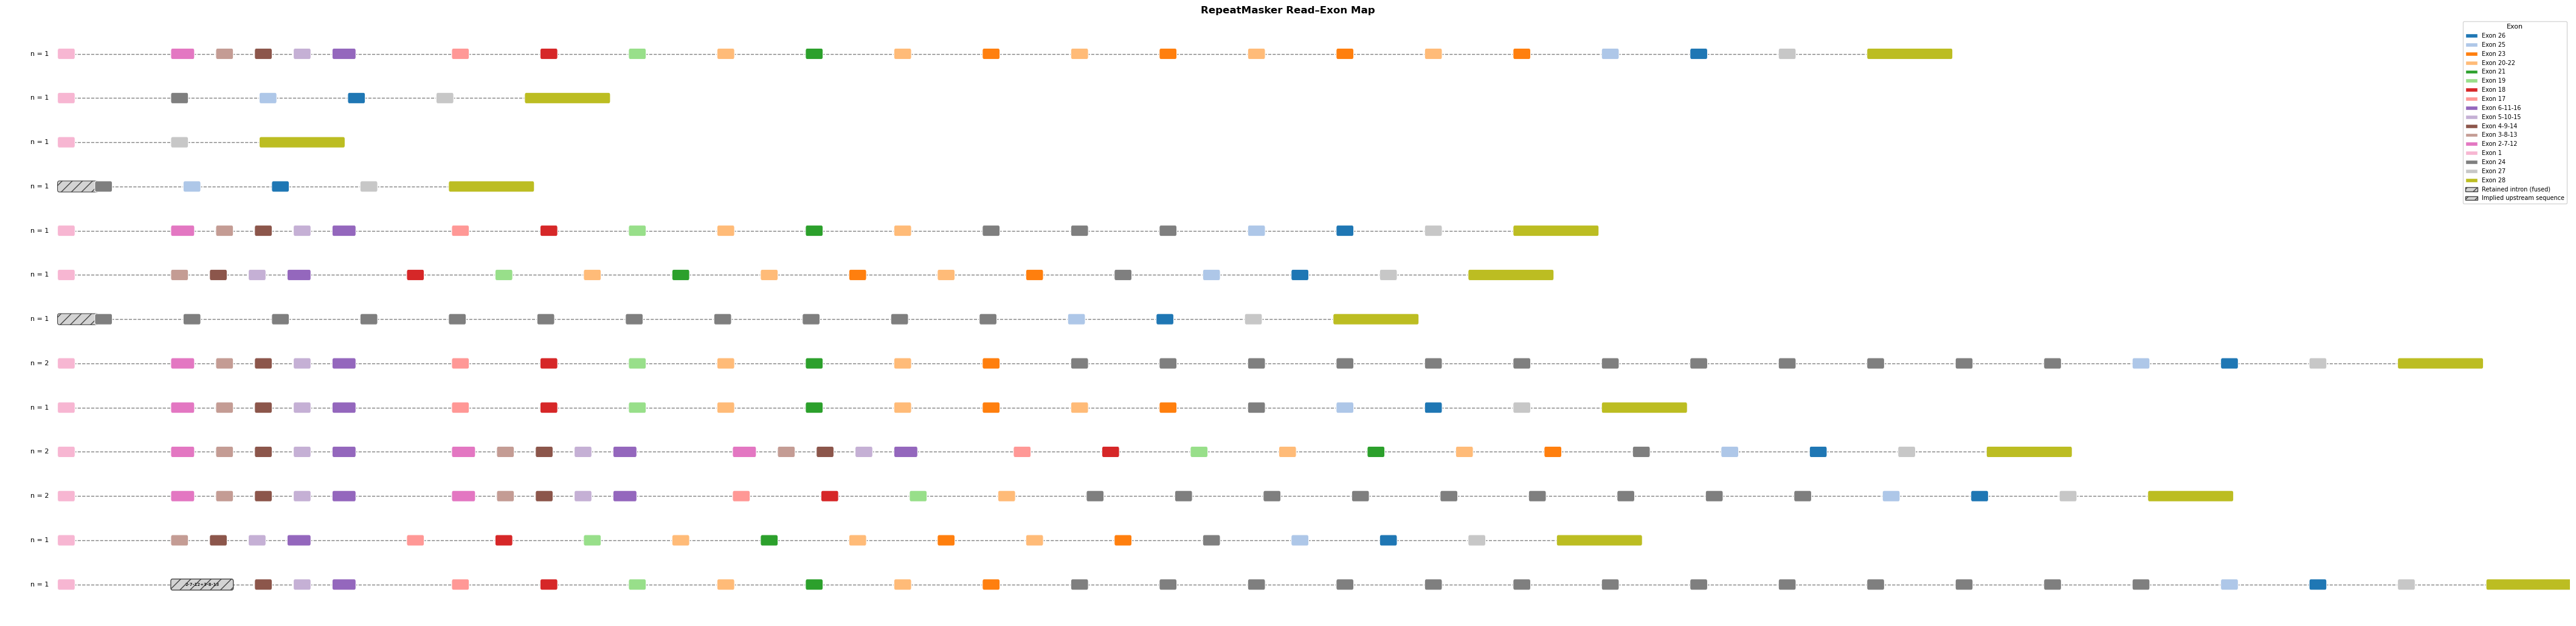

In [7]:
fig, ax = plot_repeatmasker_reads(pooledRM)
plt.savefig('pooledTestis_DAZtranscripts.png', dpi=300)
plt.show()

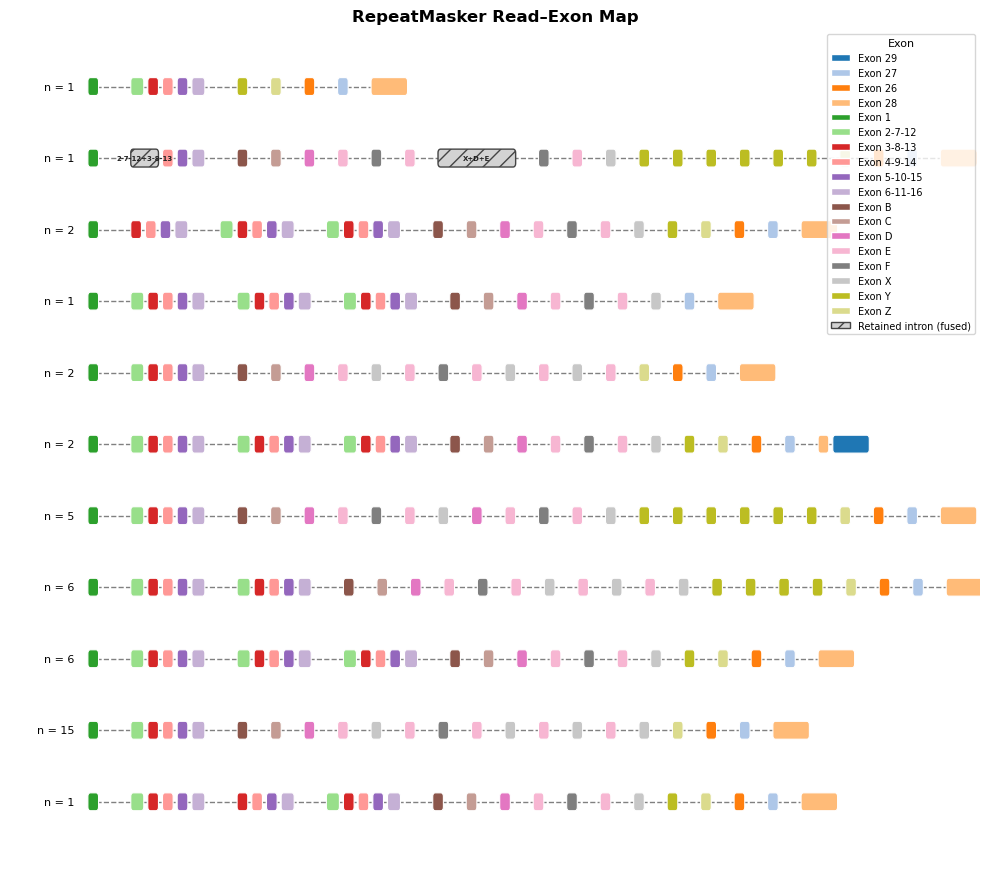

In [26]:
fig, ax = plot_repeatmasker_reads(gencodeRM)
plt.savefig('gencodeTestis_DAZtranscripts.png', dpi=300)
plt.show()

In [5]:
daz1 = ["1", "2-7-12", "3-8-13", "4-9-14", "5-10-15", "2-7-12", "3-8-13", "4-9-14", "5-10-15", "2-7-12", "3-8-13", "4-9-14", "5-10-15", '17', '18', '19', '20-22', '21', '20-22', '23', '24', '25', '26', '27', '28', '29']
daz2 = ["1", "2-7-12", "3-8-13", "4-9-14", "5-10-15", '17', '18', '19', '20-22', '21', '20-22', '23', '19', '20-22', '21', '20-22', '23', '24', '24', '24', '24', '24', '24', '25', '26', '27', '28', '29']
daz4 = ["1", "2-7-12", "3-8-13", "4-9-14", "5-10-15", "2-7-12", "3-8-13", "4-9-14", "5-10-15", '17', '18', '19', '20-22', '21', '20-22', '23', '20-22', '23', '20-22', '23', '24', '24', '24', '24', '25', '26', '27', '28', '29']
daz3 = ["1", "2-7-12", "3-8-13", "4-9-14", "5-10-15", '17', '18', '19', '20-22', '23', '20-22', '21', '20-22', '23', '20-22', '23', '20-22', '23', '25', '26', '27', '28', '29']

In [15]:
def plot_repeatmasker_reads_by_copy(df, exon_col=9, read_col=4,
                                    query_start_col=5, query_end_col=6,
                                    repeat_class_col=10, divergence_col=1,
                                    figsize_scale=1.0,
                                    required_exons=('1')):
    df = df.copy()

    raw_exon = df.iloc[:, exon_col].astype(str).str.split('EXON').str[-1].str.strip()

    df['exon_num'] = df.apply(
        lambda row: rename_exon_17(row.iloc[divergence_col], divergence_col)
            if raw_exon[row.name] == '17'
            else EXON_RENAME.get(raw_exon[row.name], raw_exon[row.name]),
        axis=1
    )

    is_simple = (
        df.iloc[:, repeat_class_col].astype(str).str.contains('Simple_repeat', case=False) |
        df.iloc[:, exon_col].astype(str).str.match(r'^\(.*\)n?$')
    )
    df = df[~is_simple].reset_index(drop=True)

    reads     = list(dict.fromkeys(df.iloc[:, read_col]))
    all_exons = list(dict.fromkeys(df['exon_num']))

    exon_colors = {e: EXON_COLORS.get(e, '#808080') for e in all_exons}
    copy_seen         = {c: {} for c in DAZ_COPIES}
    copy_struct_order = {c: [] for c in DAZ_COPIES}

    for read in reads:
        sub    = df[df.iloc[:, read_col] == read]
        exons  = list(sub['exon_num'])
        r_ends = list(clean_coord(sub.iloc[:, query_end_col]))
        r_stts = list(clean_coord(sub.iloc[:, query_start_col]))

        if infer_orientation(exons):
            exons  = exons[::-1]
            r_ends = r_ends[::-1]
            r_stts = r_stts[::-1]

        segs = build_segments(exons, r_ends, r_stts)

        if not all(has_exon(segs, e) for e in required_exons):
            continue

        copy_name, score = assign_to_copy(exons, DAZ_COPIES)
        if copy_name is None:
            continue

        key = get_structure_key(segs)
        if key not in copy_seen[copy_name]:
            copy_seen[copy_name][key] = {'segs': segs, 'count': 1, 'reads': [read]}
            copy_struct_order[copy_name].append(key)
        else:
            copy_seen[copy_name][key]['count'] += 1
            copy_seen[copy_name][key]['reads'].append(read)

    # Print read IDs per structure per copy
    for copy_name in DAZ_COPIES:
        print(f"\n{'='*60}\n{copy_name}\n{'='*60}")
        for i, key in enumerate(copy_struct_order[copy_name]):
            entry    = copy_seen[copy_name][key]
            exon_str = ' - '.join(e for seg in entry['segs'] for e in seg['exons'])
            print(f"\n  Structure {i+1} (n={entry['count']}): {exon_str}")
            for r in entry['reads']:
                print(f"    {r}")

    figures = {}
    for copy_name, copy_exons in DAZ_COPIES.items():
        structs = [copy_seen[copy_name][k] for k in copy_struct_order[copy_name]]
        fig, ax = plot_daz_copy(copy_name, copy_exons, structs,
                                all_exons, exon_colors, figsize_scale)
        figures[copy_name] = (fig, ax)

    return figures

In [32]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter

EXON_RENAME = {
    '18': 'C', '19': 'D', '20-22': 'E',
    '21': 'F', '23': 'X', '24': 'Y', '25': 'Z'
    # '17' handled separately via divergence
}
BOX_H = 0.038*15  # 0.114
def rename_list(lst):
    return [EXON_RENAME.get(e, e) for e in lst]

DAZ_COPIES = {
    'DAZ1': ["1", "2-7-12", "3-8-13", "4-9-14", "5-10-15", "6-11-16", "2-7-12", "3-8-13", "4-9-14", "5-10-15", "6-11-16", "2-7-12", "3-8-13", "4-9-14", "5-10-15", "6-11-16", 'B', 'C', 'D', 'E', 'F', 'E', 'X', 'Y', 'Z', '26', '27', '28', '29', '30'],
    'DAZ2': ["1", "2-7-12", "3-8-13", "4-9-14", "5-10-15", "6-11-16", 'A', 'C', 'D', 'E', 'F', 'E', 'X', 'D', 'E', 'F', 'E', 'X', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Z', '26', '27', '28', '29', '30'],
    'DAZ4': ["1", "2-7-12", "3-8-13", "4-9-14", "5-10-15", "6-11-16", "2-7-12", "3-8-13", "4-9-14", "5-10-15", "6-11-16", 'B', 'C', 'D', 'E', 'F', 'E', 'X', 'E', 'X', 'E', 'X', 'Y', 'Y', 'Y', 'Y', 'Z', '26', '27', '28', '29', '30'],
    'DAZ3': ["1", "2-7-12", "3-8-13", "4-9-14", "5-10-15", "6-11-16", 'B', 'C', 'D', 'E', 'X', 'E', 'F', 'E', 'X', 'E', 'X', 'E', 'X', 'Z', '26', '27', '28', '29', '30'],
}

COPIES_TO_INVERT = {'DAZ1', 'DAZ4'}

EXON_WIDTHS = {
    '2-7-12':  0.406 * 0.5,
    '6-11-16': 0.406 * 0.5,
    '28':      1.656,
    '29':      1.656,
    '30':      0.281 * 0.5 * 2,  # 0.281
}
DEFAULT_EXON_WIDTH = 0.281 * 0.5

INTRON_LENGTHS_ORDERED = {
    ('2-7-12', '6-11-16'): 2.0 * 2,   # doubled
    ('6-11-16', '2-7-12'): 2.0 * 2,   # doubled
}
SHORT_INTRON      = 0.5
DEFAULT_INTRON    = 1.5
CONTIGUITY_THRESH = 50

def clean_coord(series):
    return series.astype(str).str.replace(r'[()]', '', regex=True).astype(int)

def get_exon_width(exon, prev_exon=None, next_exon=None, for_read=False):
    if exon == '28':
        if '29' in (prev_exon, next_exon):
            return DEFAULT_EXON_WIDTH
        if for_read:
            return EXON_WIDTHS['29']
    if exon == '29':
        if '30' in (prev_exon, next_exon):
            return DEFAULT_EXON_WIDTH
    return EXON_WIDTHS.get(exon, DEFAULT_EXON_WIDTH)

def get_intron_length(exon_a, exon_b):
    pair = frozenset({exon_a, exon_b})
    
    # === Compact block: zero intron between consecutive exons ===
    # These will sit directly side-by-side
    consecutive_pairs = {
        ('2-7-12', '3-8-13'),
        ('3-8-13', '4-9-14'),
        ('4-9-14', '5-10-15'),
        ('5-10-15', '6-11-16')
    }
    
    if (exon_a, exon_b) in consecutive_pairs or (exon_b, exon_a) in consecutive_pairs:
        return 0.15
    
    # === Exception: doubled intron between "2-7-12" and "6-11-16" ===
    if pair == frozenset({'2-7-12', '6-11-16'}):
        return 6.3          # doubled (2.0 * 2)
    
    # === Your other requested increase: between exon 1 and "2-7-12" ===
    if pair == frozenset({'1', '2-7-12'}):
        return 4.5          # doubled as requested earlier
    
    # === Rest of original logic (unchanged) ===
    if pair == frozenset({'28', '29'}):
        return SHORT_INTRON * 6
    
    if exon_a == '1' or exon_b == '1':
        return 2.0
    
    if pair == frozenset({'27', '28'}):
        return DEFAULT_INTRON * 1.9
    if pair == frozenset({'26', '27'}):
        return DEFAULT_INTRON * 2.1
    if pair == frozenset({'Z', '26'}):
        return DEFAULT_INTRON * 0.25
    if exon_a == '29' or exon_b == '29':
        return 2.5
    if pair == frozenset({'29', '30'}):
        return SHORT_INTRON * 6  # same spacing as 28-29
    if exon_a == '30' or exon_b == '30':
        return 2.5
    
    if (exon_a, exon_b) in INTRON_LENGTHS_ORDERED:
        return INTRON_LENGTHS_ORDERED[(exon_a, exon_b)]
    
    if exon_a == '6-11-16' and exon_b in ('A', 'B'):
        return 2.0 * 0.5
    if exon_b == '6-11-16' and exon_a in ('A', 'B'):
        return 2.0 * 0.5
    if exon_a == '6-11-16' and exon_b != '5-10-15':
        return 2.0
    if exon_b == '6-11-16' and exon_a != '5-10-15':
        return 2.0
    
    if pair == frozenset({'Y', 'X'}) or pair == frozenset({'Y', 'F'}) or pair == frozenset({'X', 'Z'}):
        return DEFAULT_INTRON * 4.6
    
    if exon_a == 'E' or exon_b == 'E':
        return DEFAULT_INTRON
    if '-' in exon_a or '-' in exon_b:
        return SHORT_INTRON
    
    return DEFAULT_INTRON

def get_exon_sort_key(exon_str):
    try:
        return int(exon_str.split('-')[0])
    except ValueError:
        return None

def infer_orientation(exons):
    if len(exons) < 2:
        return None
    simple  = [e for e in exons if '-' not in e and e.isdigit()]
    compare = simple if len(simple) >= 2 else [e for e in exons if get_exon_sort_key(e) is not None]
    if len(compare) < 2:
        return None
    for i in range(len(compare) - 1):
        a = get_exon_sort_key(compare[i])
        b = get_exon_sort_key(compare[i + 1])
        if a != b:
            return a > b
    return None

def build_segments(exons, repeat_ends, repeat_starts):
    segments = []
    i = 0
    while i < len(exons):
        fused_exons = [exons[i]]
        while i + 1 < len(exons):
            gap = repeat_starts[i + 1] - repeat_ends[i]
            if gap > CONTIGUITY_THRESH:
                i += 1
                fused_exons.append(exons[i])
            else:
                break
        if len(fused_exons) == 1:
            prev_e = exons[i - 1] if i > 0 else None
            next_e = exons[i + 1] if i + 1 < len(exons) else None
            segments.append({
                'exons': fused_exons,
                'fused': False,
                'width': get_exon_width(fused_exons[0], prev_e, next_e, for_read=True),
            })
        else:
            total_w = get_exon_width(
                fused_exons[0],
                exons[i - len(fused_exons)] if i - len(fused_exons) >= 0 else None,
                fused_exons[1] if len(fused_exons) > 1 else None,
                for_read=True
            )
            for j in range(1, len(fused_exons)):
                total_w += get_intron_length(fused_exons[j-1], fused_exons[j])
                next_e   = fused_exons[j + 1] if j + 1 < len(fused_exons) else None
                total_w += get_exon_width(fused_exons[j], fused_exons[j-1], next_e, for_read=True)
            segments.append({
                'exons': fused_exons,
                'fused': True,
                'width': total_w,
            })
        i += 1
    return segments

def build_exon_colors(exon_color_dict):
    """
    Convert the raw exonColors dict (original names, no # prefix)
    to use renamed exon names and proper hex format.
    Exon 17 maps to both 'A' and 'B' since both are renamed from 17.
    """
    colors = {}
    for raw_name, hex_val in exon_color_dict.items():
        color = f'#{hex_val}'
        # Apply rename
        renamed = EXON_RENAME.get(raw_name, raw_name)
        colors[renamed] = color
        # Exon 17 applies to both A and B
        if raw_name == '17':
            colors['A'] = color
            colors['B'] = color
    return colors

exonColors = {
    "1":      "FFC0CB",
    "2-7-12": "ADD8E6",
    "3-8-13": "000000",
    "4-9-14": "FF0101",
    "5-10-15":"007F00",
    "6-11-16":"800080",
    "17":     "FFFF01",
    '18':     'FFFF01',
    '19':     'FFFF01',
    '20-22':  'FFFF01',
    '21':     'FFFF01',
    '23':     'FFFF01',
    '24':     'FFFF01',
    '25':     'FFFF01',
    '26':     "01FF01",
    '27':     '808080',
    '28':     '3853A4',
    '29':     '6C17E5',
    '30':     'FF6600',   # orange — pick any color you prefer
}
EXON_COLORS = build_exon_colors(exonColors)

def get_structure_key(segs):
    return tuple((tuple(s['exons']), s['fused']) for s in segs)

def has_exon(segs, exon):
    return any(exon in seg['exons'] for seg in segs)

def assign_to_copy(read_exons, daz_copies):
    any_copy_exons = set(e for exons in daz_copies.values() for e in exons)
    read_counts    = Counter(read_exons)

    best_copy  = None
    best_score = -1

    for copy_name, copy_exons in daz_copies.items():
        copy_counts = Counter(copy_exons)
        if any(
            read_counts[e] > copy_counts[e]
            for e in read_counts
            if e in any_copy_exons
        ):
            continue
        score = sum(min(read_counts[e], copy_counts[e])
                    for e in read_counts if e in copy_counts)
        if score > best_score:
            best_score = score
            best_copy  = copy_name

    return best_copy, best_score

def build_copy_axis(copy_exons):
    axis   = []
    cursor = 0.0
    for i, e in enumerate(copy_exons):
        prev_e = copy_exons[i - 1] if i > 0 else None
        next_e = copy_exons[i + 1] if i + 1 < len(copy_exons) else None
        w      = get_exon_width(e, prev_e, next_e)
        axis.append({'exon': e, 'x': cursor, 'width': w})
        if i < len(copy_exons) - 1:
            cursor += w + get_intron_length(e, copy_exons[i + 1])
    return axis

def match_read_to_axis(read_exons, axis):
    axis_used = [False] * len(axis)
    matched   = []
    axis_ptr  = 0
    for e in read_exons:
        found = False
        for j in range(axis_ptr, len(axis)):
            if axis[j]['exon'] == e and not axis_used[j]:
                matched.append(axis[j])
                axis_used[j] = True
                axis_ptr     = j + 1
                found        = True
                break
        if not found:
            return None
    return matched

def get_axis_label(exon, occurrence_count):
    if '-' in exon:
        parts = exon.split('-')
        idx   = occurrence_count % len(parts)
        return parts[idx]
    return exon

def rename_exon_17(divergence, divergence_col):
    """Return 'A' if divergence > 0, else 'B'."""
    try:
        div = float(str(divergence).strip())
        return 'A' if div > 0 else 'B'
    except ValueError:
        return 'B'

COPIES_TO_INVERT = {'DAZ1', 'DAZ4'}

def plot_daz_copy(copy_name, copy_exons, structs, all_exons, exon_colors,
                  figsize_scale=1.0):
    FUSED_EDGE = '#444444'
    box_h      = BOX_H  # use global constant


    if not structs:
        print(f"No reads assigned to {copy_name}")
        return None, None

    # Always build axis in original order for matching
    axis      = build_copy_axis(copy_exons)
    max_track = axis[-1]['x'] + axis[-1]['width']

    # For inverted copies, mirror all x positions: x_new = max_track - x_old - width
    def mirror_x(x, w):
        return max_track - x - w

    invert = copy_name in COPIES_TO_INVERT

    n_structs = len(structs)
    fig_w = max(10, max_track * 0.6) * figsize_scale
    fig_h = max(4,  n_structs * 0.8) * figsize_scale
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    # Reference axis track — draw in mirrored positions if inverted
    ref_y             = -1
    # For label ordering, reverse occurrence counting if inverted
    occurrence_counts = {}
    # Pre-count total occurrences per exon for inverted labelling
    total_counts = Counter(entry['exon'] for entry in axis)
    used_counts  = {}

    for i, entry in enumerate(axis):
        x, w, e = entry['x'], entry['width'], entry['exon']

        if invert:
            x = mirror_x(entry['x'], w)

        occ                  = occurrence_counts.get(e, 0)
        occurrence_counts[e] = occ + 1

        # For inverted copies, label from the end of the occurrence list
        if invert:
            display_occ = total_counts[e] - 1 - occ
        else:
            display_occ = occ

        label = get_axis_label(e, display_occ)

        rect = mpatches.FancyBboxPatch(
            (x, ref_y - box_h / 2), w, box_h,
            boxstyle="round,pad=0.05",
            facecolor=exon_colors.get(e, 'grey'), edgecolor='black',
            linewidth=0.8, zorder=2, alpha=0.3
        )
        ax.add_patch(rect)
        ax.text(x + w / 2, ref_y, label, ha='center', va='center',
                fontsize=5, color='black', fontweight='bold', zorder=3)

        if i < len(axis) - 1:
            next_entry = axis[i + 1]
            if invert:
                next_x = mirror_x(next_entry['x'], next_entry['width'])
                ax.plot([x, next_x + next_entry['width']], [ref_y, ref_y],
                        color='lightgrey', lw=0.8, linestyle='--', zorder=1)
            else:
                ax.plot([x + w, next_entry['x']], [ref_y, ref_y],
                        color='lightgrey', lw=0.8, linestyle='--', zorder=1)

    for row_idx, entry in enumerate(structs):
        segs  = entry['segs']
        count = entry['count']
        y     = row_idx

        read_exons_flat = [e for seg in segs for e in seg['exons']]
        matched         = match_read_to_axis(read_exons_flat, axis)
        if matched is None:
            continue

        seg_positions = []
        i = 0
        for seg in segs:
            n           = len(seg['exons'])
            seg_matched = matched[i:i + n]
            i          += n
            if not seg_matched:
                continue
            x_start = seg_matched[0]['x']
            x_end   = seg_matched[-1]['x'] + seg_matched[-1]['width']

            # Mirror positions for inverted copies first
            if invert:
                x_start = max_track - (seg_matched[-1]['x'] + seg_matched[-1]['width'])
                x_end   = max_track - seg_matched[0]['x']

            # Then apply exon 28 extension after mirroring
            if (not seg['fused'] and seg['exons'] == ['28']
                    and not has_exon(segs, '29')):
                extra = EXON_WIDTHS['29'] - (x_end - x_start)
                if invert:
                    x_start -= extra
                else:
                    x_end += extra

            # Apply exon 29 extension after mirroring
            if (not seg['fused'] and seg['exons'] == ['29']
                    and not has_exon(segs, '30')):
                extra = EXON_WIDTHS['29'] - (x_end - x_start)
                if invert:
                    x_start -= extra
                else:
                    x_end += extra

            seg_positions.append((seg, x_start, x_end))

        if seg_positions:
            ax.plot([seg_positions[0][1], seg_positions[-1][2]], [y, y],
                    color='#333333', lw=0.8, linestyle='-', zorder=1)

        for seg, x_start, x_end in seg_positions:
            w = x_end - x_start
            if seg['fused']:
                rect = mpatches.FancyBboxPatch(
                    (x_start, y - box_h / 2), w, box_h,
                    boxstyle="round,pad=0.05",
                    facecolor='lightgrey', edgecolor='black',
                    linewidth=0.5, zorder=2, hatch='//'
                )
                ax.add_patch(rect)
                
            else:
                e    = seg['exons'][0]
                rect = mpatches.FancyBboxPatch(
                    (x_start, y - box_h / 2), w, box_h,
                    boxstyle="round,pad=0.05",
                    facecolor=exon_colors.get(e, '#808080'), edgecolor='black',
                    linewidth=0.5, zorder=2
                )
                ax.add_patch(rect)

        ax.text(-0.3 if not invert else max_track + 0.3, y,
                f'n = {count}',
                ha='right' if not invert else 'left',
                va='center', fontsize=8)

    ax.set_xlim(-1.5, max_track + 1.5)
    ax.set_ylim(-1.5, n_structs - 0.2)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines[['left', 'right', 'top', 'bottom']].set_visible(False)
    ax.set_title(f'RepeatMasker Read–Exon Map — {copy_name}',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    return fig, ax

def plot_repeatmasker_reads_by_copy(df, exon_col=9, read_col=4,
                                    query_start_col=5, query_end_col=6,
                                    repeat_class_col=10, divergence_col=1,
                                    figsize_scale=1.0,
                                    required_exons=('1', '28')):
    df = df.copy()

    # Extract raw exon name first for the 17 check
    raw_exon = df.iloc[:, exon_col].astype(str).str.split('EXON').str[-1].str.strip()

    # Rename exon 17 based on divergence, all others via EXON_RENAME
    df['exon_num'] = raw_exon.where(raw_exon != '17', other=None)
    df['exon_num'] = df.apply(
        lambda row: rename_exon_17(row.iloc[divergence_col], divergence_col)
            if raw_exon[row.name] == '17'
            else EXON_RENAME.get(raw_exon[row.name], raw_exon[row.name]),
        axis=1
    )

    # Remove simple repeats
    is_simple = (
        df.iloc[:, repeat_class_col].astype(str).str.contains('Simple_repeat', case=False) |
        df.iloc[:, exon_col].astype(str).str.match(r'^\(.*\)n?$')
    )
    df = df[~is_simple].reset_index(drop=True)

    reads     = list(dict.fromkeys(df.iloc[:, read_col]))
    all_exons = list(dict.fromkeys(df['exon_num']))

    # Replace these lines:
    # cmap        = plt.get_cmap('tab20')
    # exon_colors = {e: cmap(i % 20) for i, e in enumerate(all_exons)}

    # With:
    exon_colors = {e: EXON_COLORS.get(e, '#808080') for e in all_exons}
    copy_seen         = {c: {} for c in DAZ_COPIES}
    copy_struct_order = {c: [] for c in DAZ_COPIES}

    for read in reads:
        sub    = df[df.iloc[:, read_col] == read]
        exons  = list(sub['exon_num'])
        r_ends = list(clean_coord(sub.iloc[:, query_end_col]))
        r_stts = list(clean_coord(sub.iloc[:, query_start_col]))

        if infer_orientation(exons):
            exons  = exons[::-1]
            r_ends = r_ends[::-1]
            r_stts = r_stts[::-1]

        segs = build_segments(exons, r_ends, r_stts)

        if not all(has_exon(segs, e) for e in required_exons):
            continue

        copy_name, score = assign_to_copy(exons, DAZ_COPIES)
        if copy_name is None:
            continue

        key = get_structure_key(segs)
        if key not in copy_seen[copy_name]:
            copy_seen[copy_name][key] = {'segs': segs, 'count': 1}
            copy_struct_order[copy_name].append(key)
        else:
            copy_seen[copy_name][key]['count'] += 1

    figures = {}
    for copy_name, copy_exons in DAZ_COPIES.items():
        structs  = [copy_seen[copy_name][k] for k in copy_struct_order[copy_name]]
        fig, ax  = plot_daz_copy(copy_name, copy_exons, structs,
                                 all_exons, exon_colors, figsize_scale)
        figures[copy_name] = (fig, ax)

    return figures

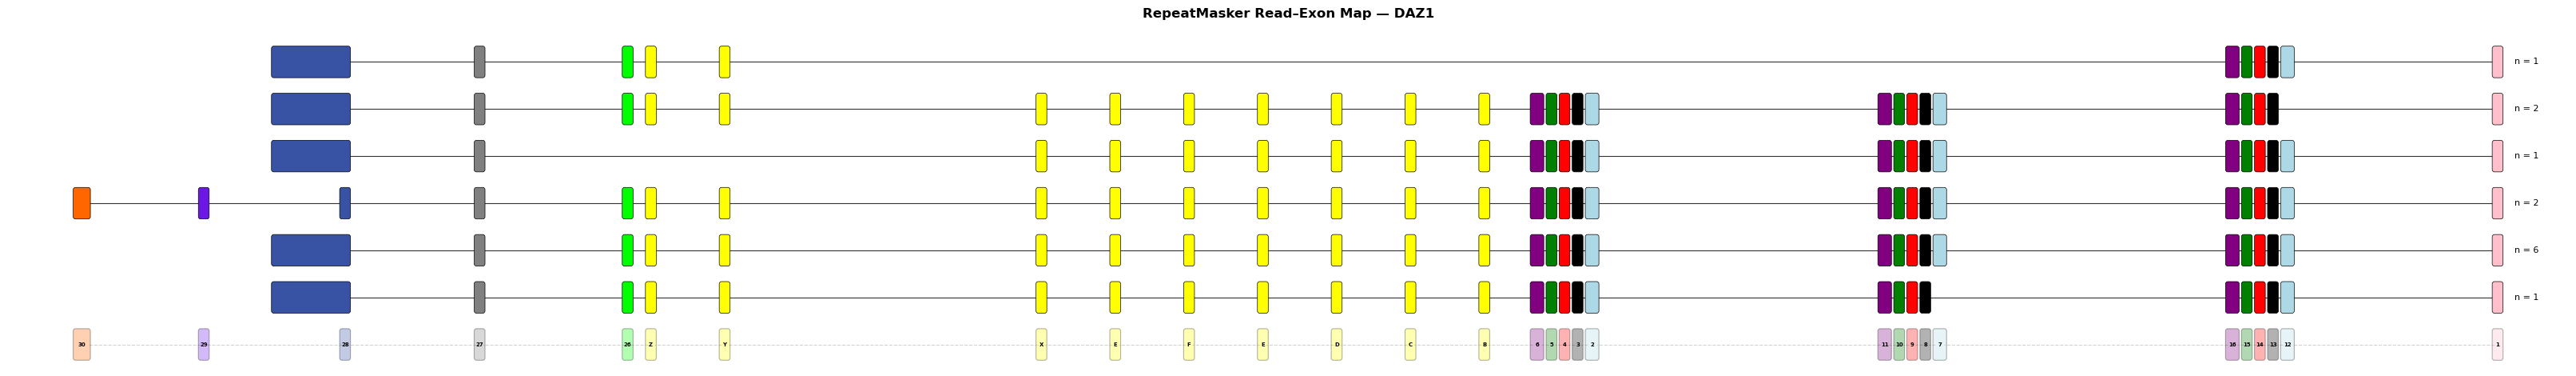

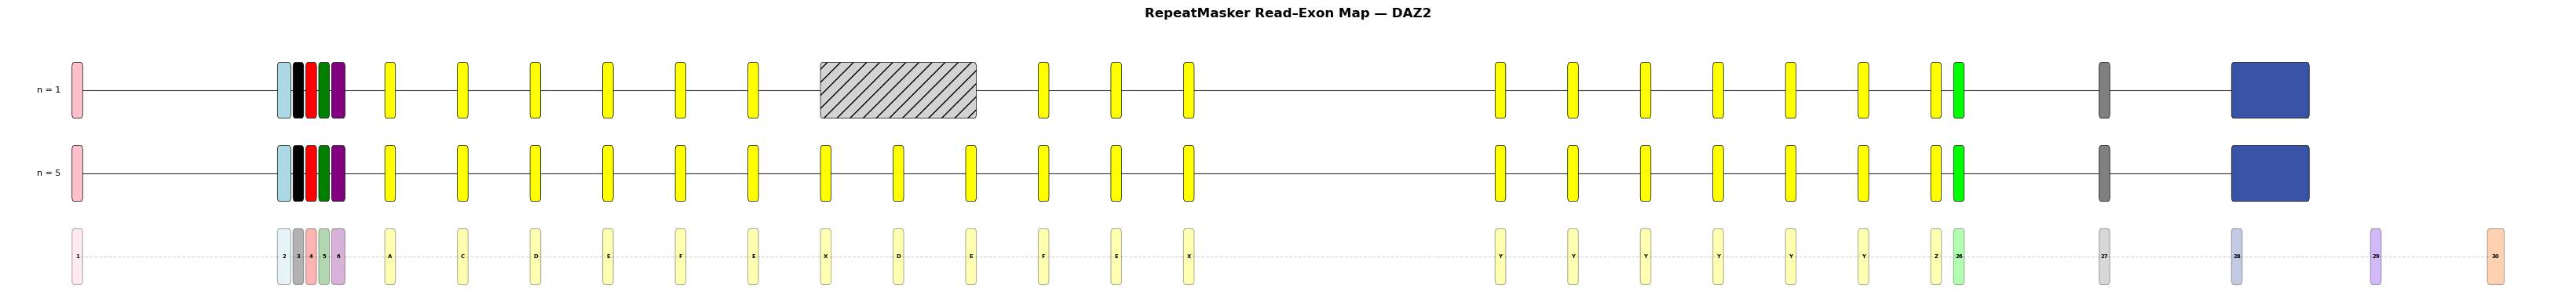

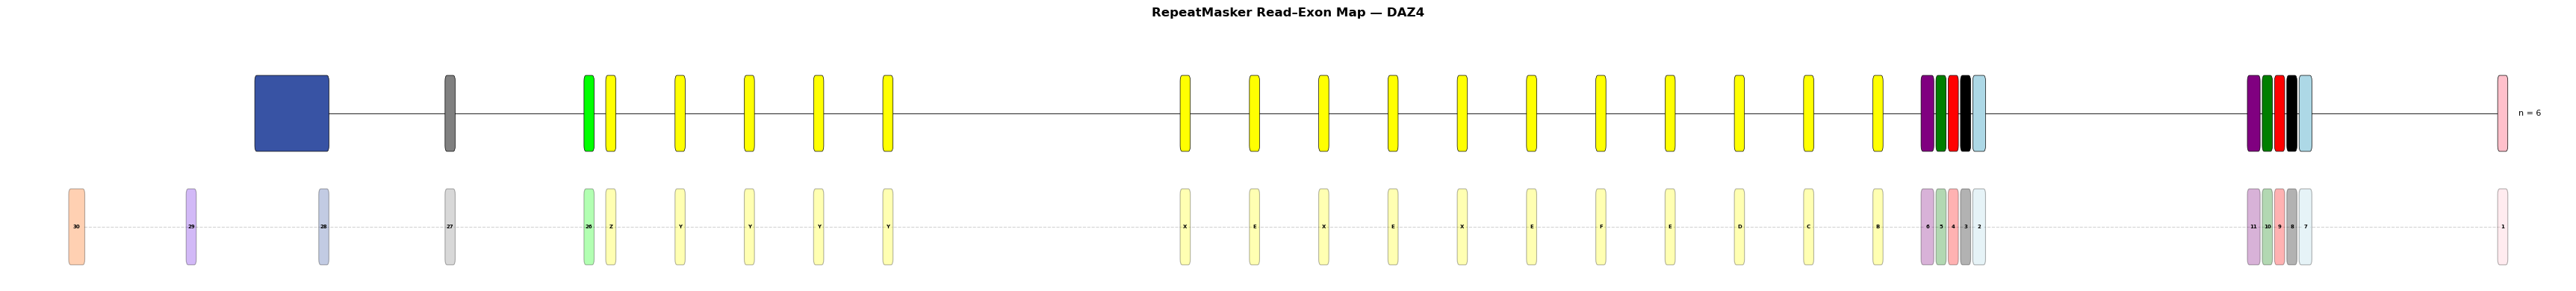

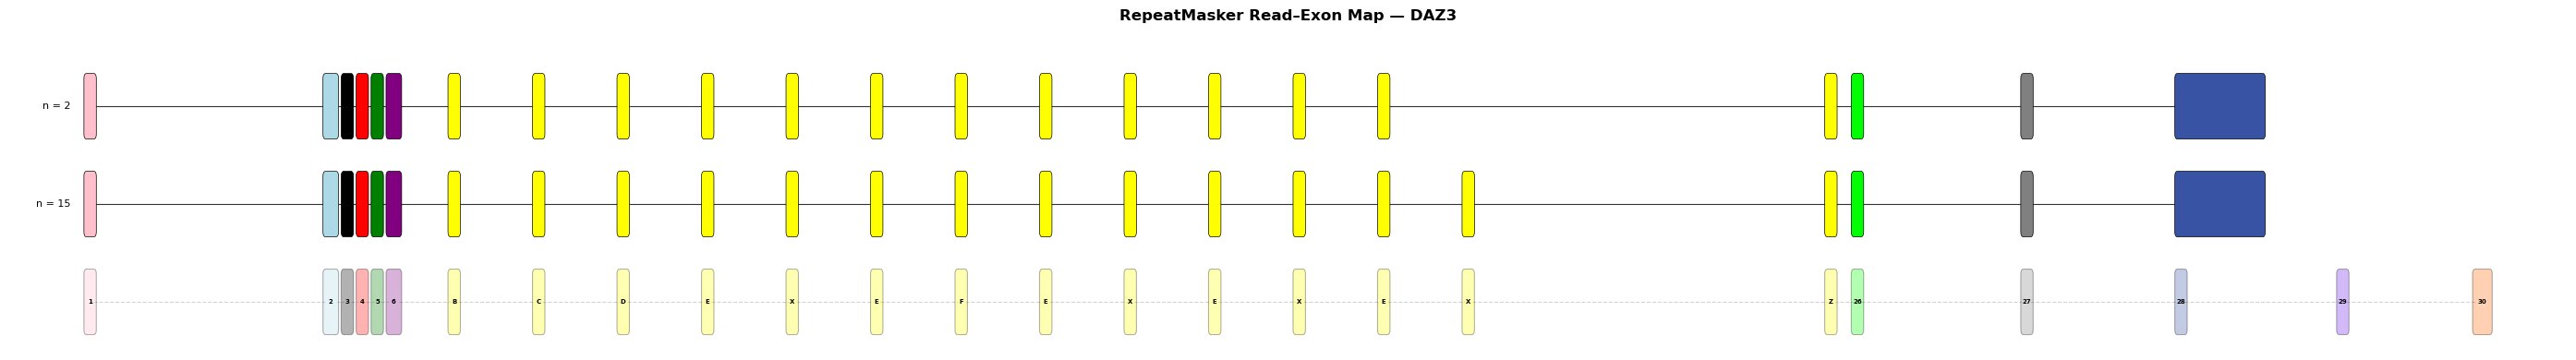

In [33]:
figures = plot_repeatmasker_reads_by_copy(gencodeRM)
for copy_name, (fig, ax) in figures.items():
    if fig is not None:
        fig.savefig(f'{copy_name}_reads.png', dpi=300)
        fig.savefig(f'{copy_name}_reads.pdf', dpi=300)

plt.show()

No reads assigned to DAZ2
No reads assigned to DAZ4


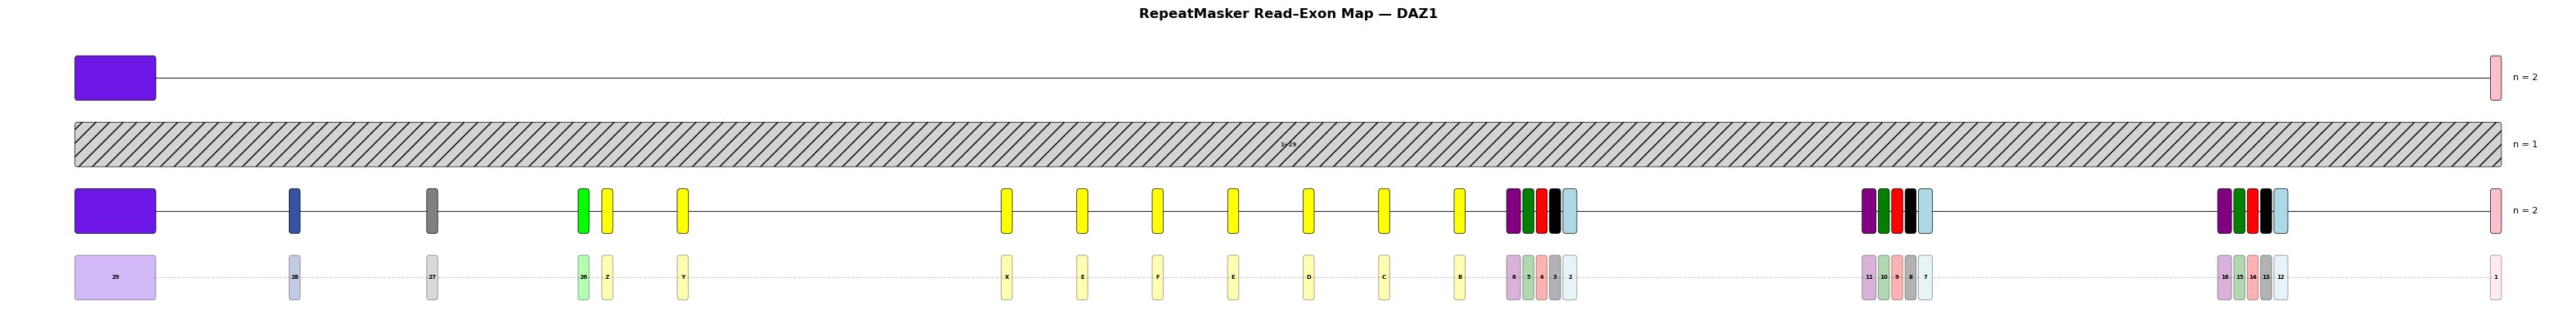

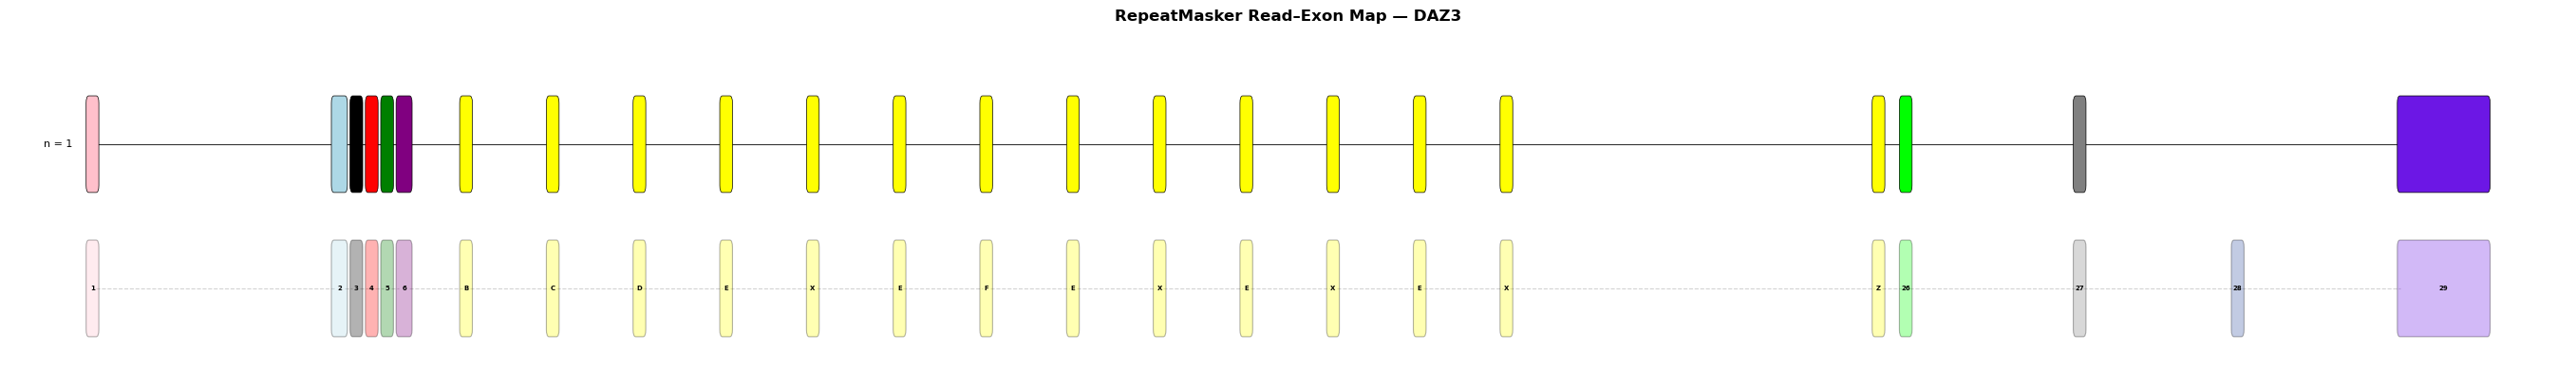

In [22]:
figures = plot_repeatmasker_reads_by_copy(gencodeRM)
for copy_name, (fig, ax) in figures.items():
    if fig is not None:
        fig.savefig(f'{copy_name}_reads_exon29.png', dpi=300)
        fig.savefig(f'{copy_name}_reads_exon29.pdf', dpi=300)

plt.show()

In [7]:
seq = "GGCCTCTGTTCCTCCTTGAGCCTGTCGGGAGCTGCTGCCTGCCACCACCATGTCTGCTGCAAATCCTGAGACTCCAAACTCAACCATCTCCAGAGAGGCCAGCACCCAGTCTTCATCAGCTGCAGCTAGCCAAGGCTGGGTGTTACCAGAAGGCAAAATCGTGCCAAACACTGTTTTTGTTGGTGGAATTGATGCTAGGATGGATGAAACTGAGATTGGAAGCTGCTTTGGTAGATACGGTTCAGTGAAAGAAGTGAAGATAATCACGAATCGAACTGGTGTGTCCAAAGGCTATGGATTTGTTTCGTTTGTTAATGACGTGGATGTCCAGAAGATAGTAGGATCACAGATACATTTCCATGGTAAAAAGCTGAAGCTGGGCCCTGCAATCAGGAAACAAAAGTTATGTGCTCGTCATGTGCAGCCACGTCCTTTGGTAGTTAATCCTCCTCCTCCACCACAGTTTCAGAACGTCTGGCGGAATCCAAACACTGAAACCTACCTGCAGCCCCAAATCACGCCGAATCCTGTAACTCAGCACGTTCAGTCTGCTGCAAATCCTGAGACTCCAAACTCAACCATCTCCAGAGAGGCCAGCACCCAGTCTTCATCAGCTGCAGCTAGCCAAGGCTGGGTGTTACCAGAAGGCAAAATCGTGCCAAACACTGTTTTTGTTGGTGGAATTGATGCTAGGATGGATGAAACTGAGATTGGAAGCTGCTTTGGTAGATACGGTTCAGTGAAAGAAGTGAAGATAATCACGAATCGAACTGGTGTGTCCAAAGGCTATGGATTTGTTTCGTTTGTTAATGACGTGGATGTCCAGAAGATAGTAGGATCACAGATACATTTCCATGGTAAAAAGCTGAAGCTGGGCCCTGCAATCAGGAAACAAAAGTTATGTGCTCGTCATGTGCAGCCACGTCCTTTGGTAGTTAATCCTCCTCCTCCACCACAGTTTCAGAACGTCTGGCGGAATCCAAACACTGAAACCTACCTGCAGCCCCAAATCACGCCGAATCCTGTAACTCAGCACGTTCAGTCTGCTGCAAATCCTGAGACTCCAAACTCAACCATCTCCAGAGAGGCCAGCACCCAGTCTTCATCAGCTGCAGCTAGCCAAGGCTGGGTGTTACCAGAAGGCAAAATCGTGCCAAACACTGTTTTTGTTGGTGGAATTGATGCTAGGATGGATGAAACTGAGATTGGAAGCTGCTTTGGTAGATACGGTTCAGTGAAAGAAGTGAAGATAATCACGAATCGAACTGGTGTGTCCAAAGGCTATGGATTTGTTTCGTTTGTTAATGACGTGGATGTCCAGAAGATAGTAGGATCACAGATACATTTCCATGGTAAAAAGCTGAAGCTGGGCCCTGCAATCAGGAAACAAAAGTTATGTGCTCGTCATGTGCAGCCACGTCCTTTGGTAGTTAATCCTCCTCCTCCACCACAGTTTCAGAACGTCTGGCGGAATCCAAACACTGAAACCTACCTGCAGCCCCAAATCACGCCGAATCCTGTAACTCAGCACGTTCAGGCTTACTCTGCTTATCCACATTCACCAGGTCAGGTCATCACTGGATGTCAGTTGCTTGTATATAATTATCAGGAATATCCTACTTATCCCGATTCAGCATTTCAGGTCACCACTGGATATCAGTTGCCTGTATATAATTATCAGCCATTTCCTGCTTATCCAAGATCACCATTTCAGGTCACTGCTGGATATCAGTTGCCTGTATATAATTATCAGGCATTTCCTGCTTATCCAAATTCACCATTTCAAGTCGCCACTGGATATCAGTTCCCTGTATACAATTATCAGCCATTTCCTGCTTATCCAAGTTCACCATTTCAGGTCACTGCTGGATATCAGTTGCCTGTATATAATTATCAGGCATTTCCTGCTTATCCAAATTCACCATTTCAAGTCGCCACTGGATATCAGTTCCCTGTATACAATTATCAGGCATTTCCTGCTTATCCAAATTCACCAGTTCAGGTCACCACTGGATATCAGTTGCCTGTATACAATTATCAGGCATTTCCTGCTTATCCAAGTTCACCATTTCAGGTCACCACTGGATATCAGTTGCCTGTATATAATTATCAGGCATTTCCTGCTTATCCAAATTCAGCAGTTCAGGTCACCACTGGATATCAGTTCCATGTATACAATTACCAGATGCCACCGCAGTGCCCTGTTGGGGAGCAAAGGAGAAATCTGTGGACCGAAGCATACAAATGGTGGTATCTTGTCTGTTTAATCCAGAGAAGAGACTGATAAATTCCGTTGTTACTCAAGATGACTGCTTCAAGGGTAAAAGAGTGCATCGCTTTAGAAGAAGTTTGGCAGTATTTAAATCTGTTGGATCCTCTCAGCTATCTAGTTTCATGGGAAGTTGCTGGTTTTGAATATTAAGCTAAAAGTTTTCCACTATTACAGAAATTCTGAATTTTGAATCTTGTTCTGCCTCCCAGACTTGAGTGCAATGGCACGATCTCGACTCACTGCAACCTCGGCCTCCCAGGTTCAAGCAATTCTCCTGCCTCAGTCTTCTGAATAGCTGGGATTACAGGCACGTGCCACCATGCCCGGTTGGAGTTTCCATGGCACCCAGAAGACCAGGGATCCTGGTAAGAAAGTTTTAAAACGCTGAAGTGGTAAGTTTGTAAATTTGTGATACCTGGTGTCAAGTCCTACTTCAGGAATCTACAAAAATTGGGCCTTTTGAATAGAAGTGTTTTAGTGAATAATGAGTGATGTGGCAACTTATTCTGATAATATTTCAATCTAGCTTTTTGCTTTTAATGGTAGTTGCCATTTCTATTGGGCTGCATCATTCCCAGGAAAGCCTTCTTTTAAAATCAGTACAGGATGTGTGCATCCTAATACAAAAATCCCAAATCCAGAAATGCCCCTGAATCTGAAAGTTTTTCAGTGCTAATATGAGATAGTGAAACCTTTGCTTTCAGATGGTTCAGTGTACAAAAACATTGTTTCATAGACAAAATTATTTAAGGTGTTGTATAAAATTACTTTCAGACTATGTGCCTAAGGTATATATGAAACATAAATGAATTCCATGTTTAGATTTGGGTCTCACTCCCAGATATCTCATTATATATATGCAAATATTCC"
seq[-543:]

'TTGGAGTTTCCATGGCACCCAGAAGACCAGGGATCCTGGTAAGAAAGTTTTAAAACGCTGAAGTGGTAAGTTTGTAAATTTGTGATACCTGGTGTCAAGTCCTACTTCAGGAATCTACAAAAATTGGGCCTTTTGAATAGAAGTGTTTTAGTGAATAATGAGTGATGTGGCAACTTATTCTGATAATATTTCAATCTAGCTTTTTGCTTTTAATGGTAGTTGCCATTTCTATTGGGCTGCATCATTCCCAGGAAAGCCTTCTTTTAAAATCAGTACAGGATGTGTGCATCCTAATACAAAAATCCCAAATCCAGAAATGCCCCTGAATCTGAAAGTTTTTCAGTGCTAATATGAGATAGTGAAACCTTTGCTTTCAGATGGTTCAGTGTACAAAAACATTGTTTCATAGACAAAATTATTTAAGGTGTTGTATAAAATTACTTTCAGACTATGTGCCTAAGGTATATATGAAACATAAATGAATTCCATGTTTAGATTTGGGTCTCACTCCCAGATATCTCATTATATATATGCAAATATTCC'

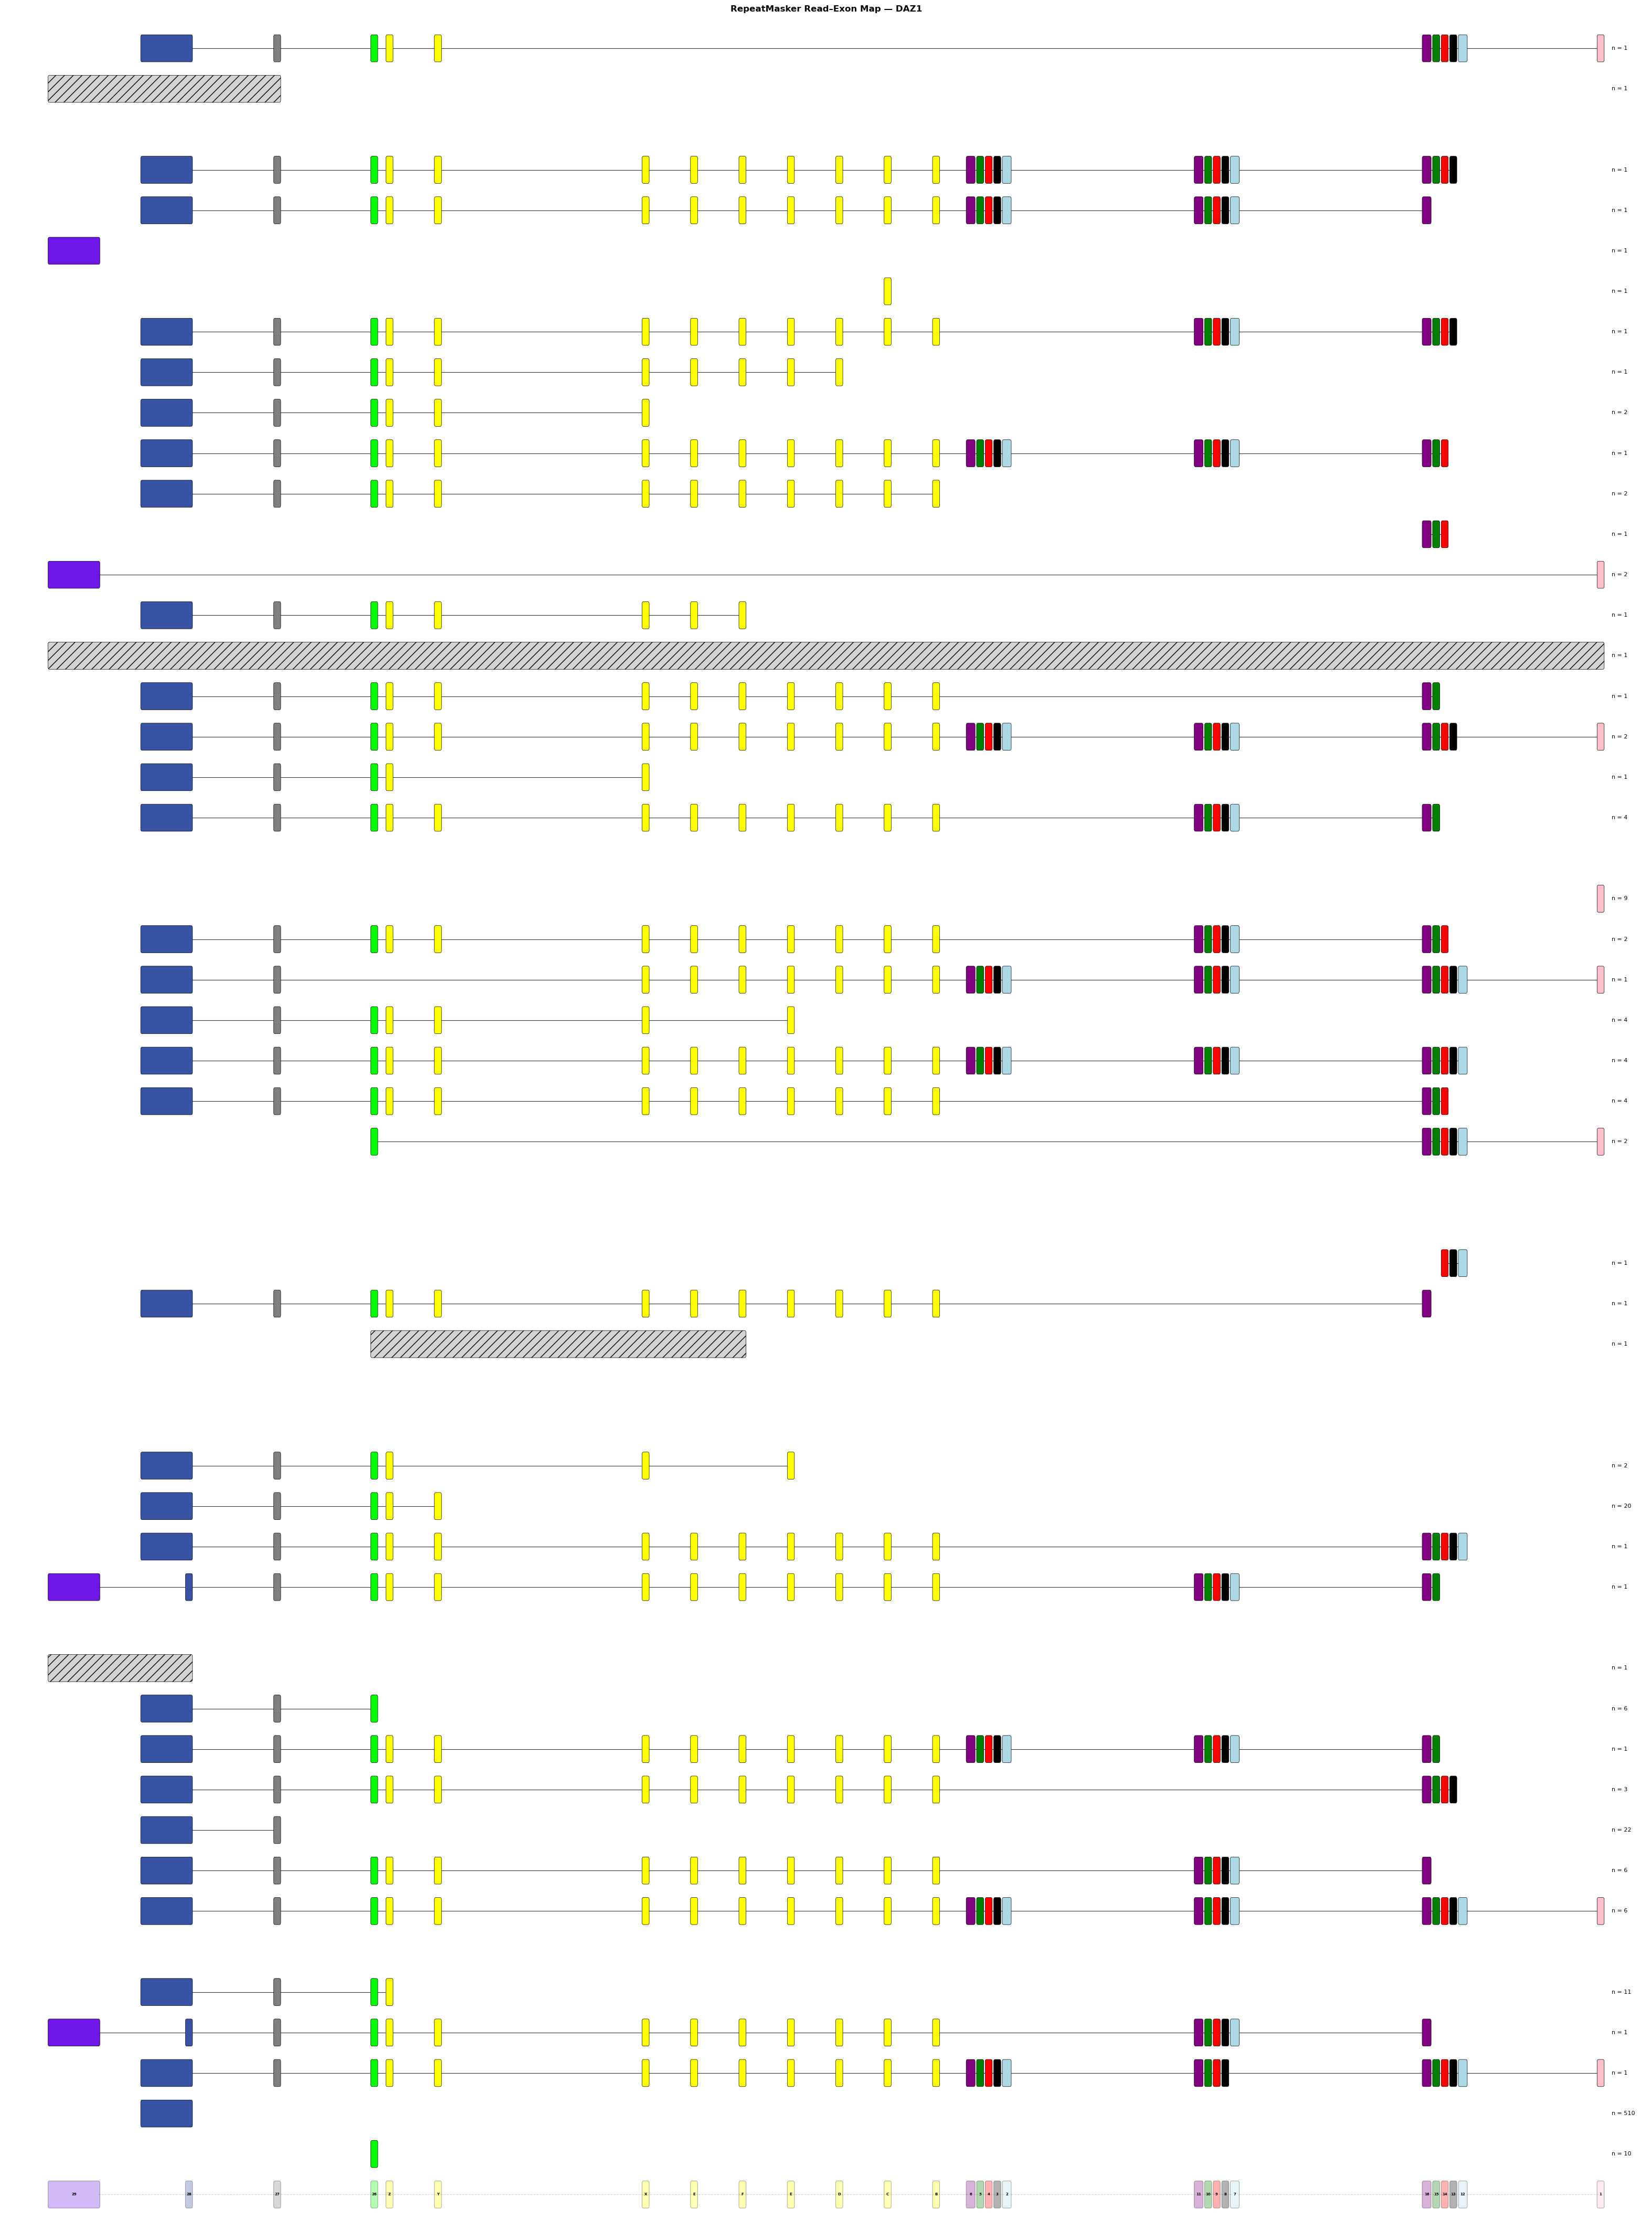

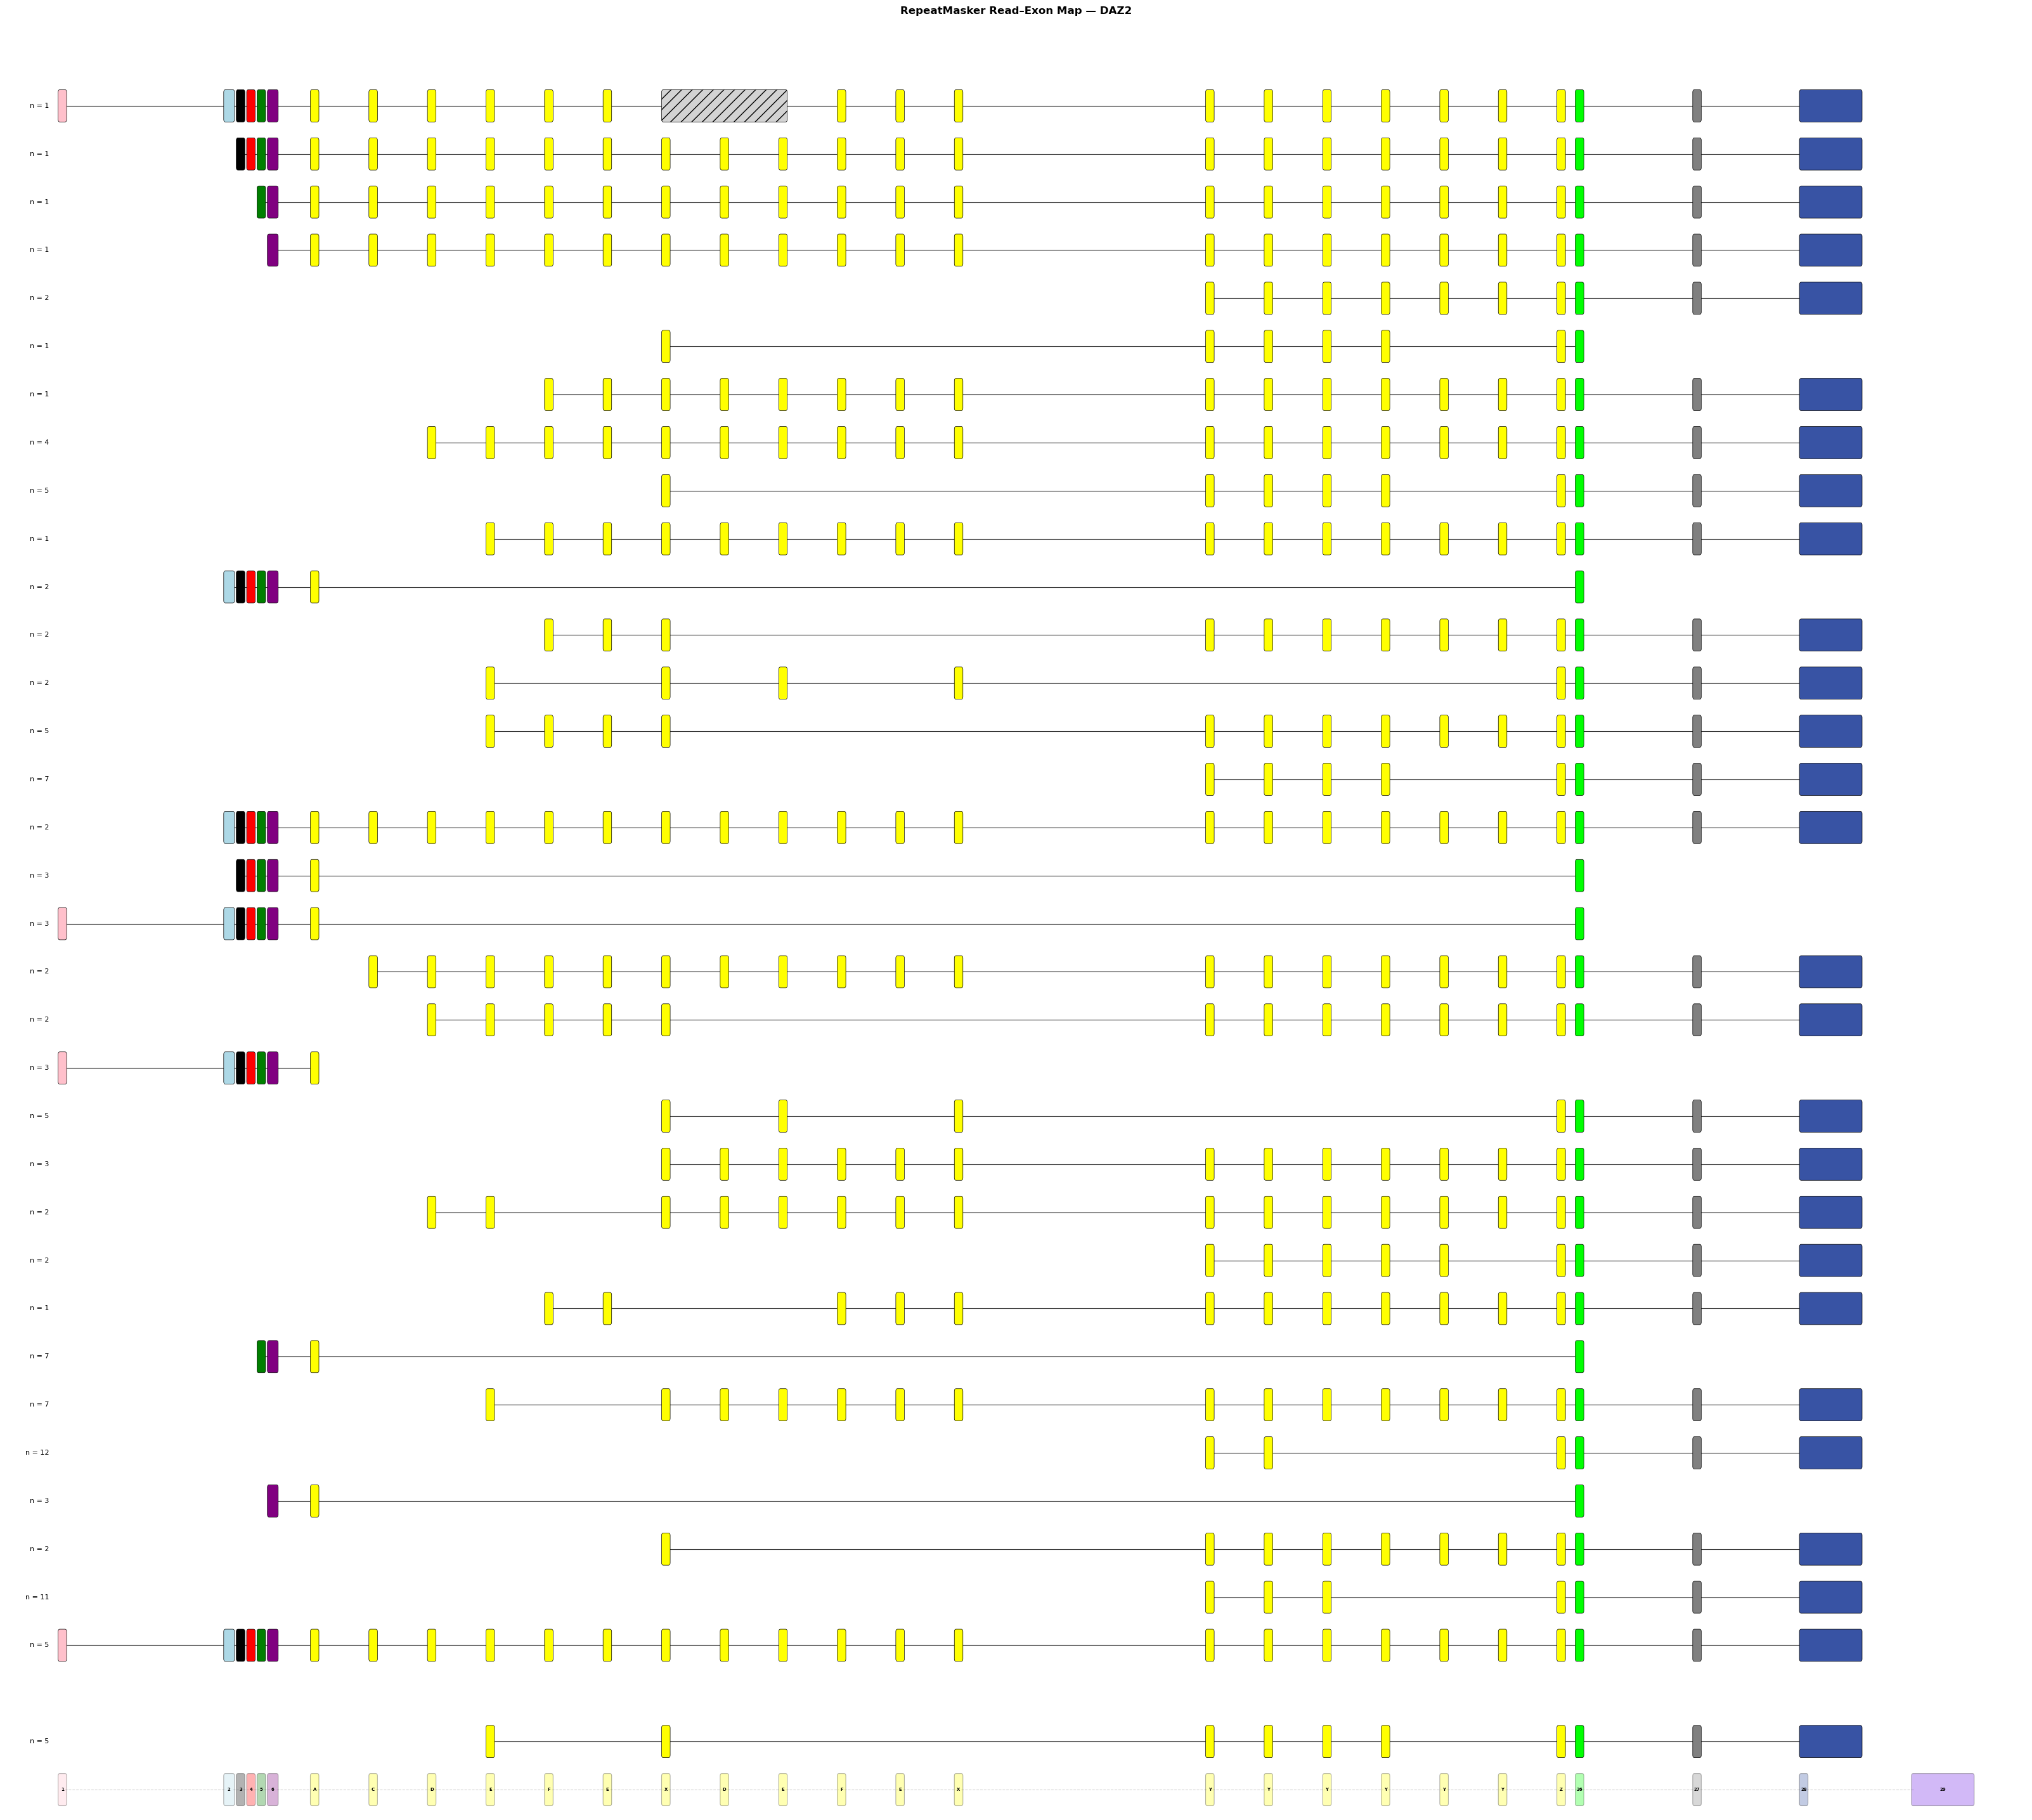

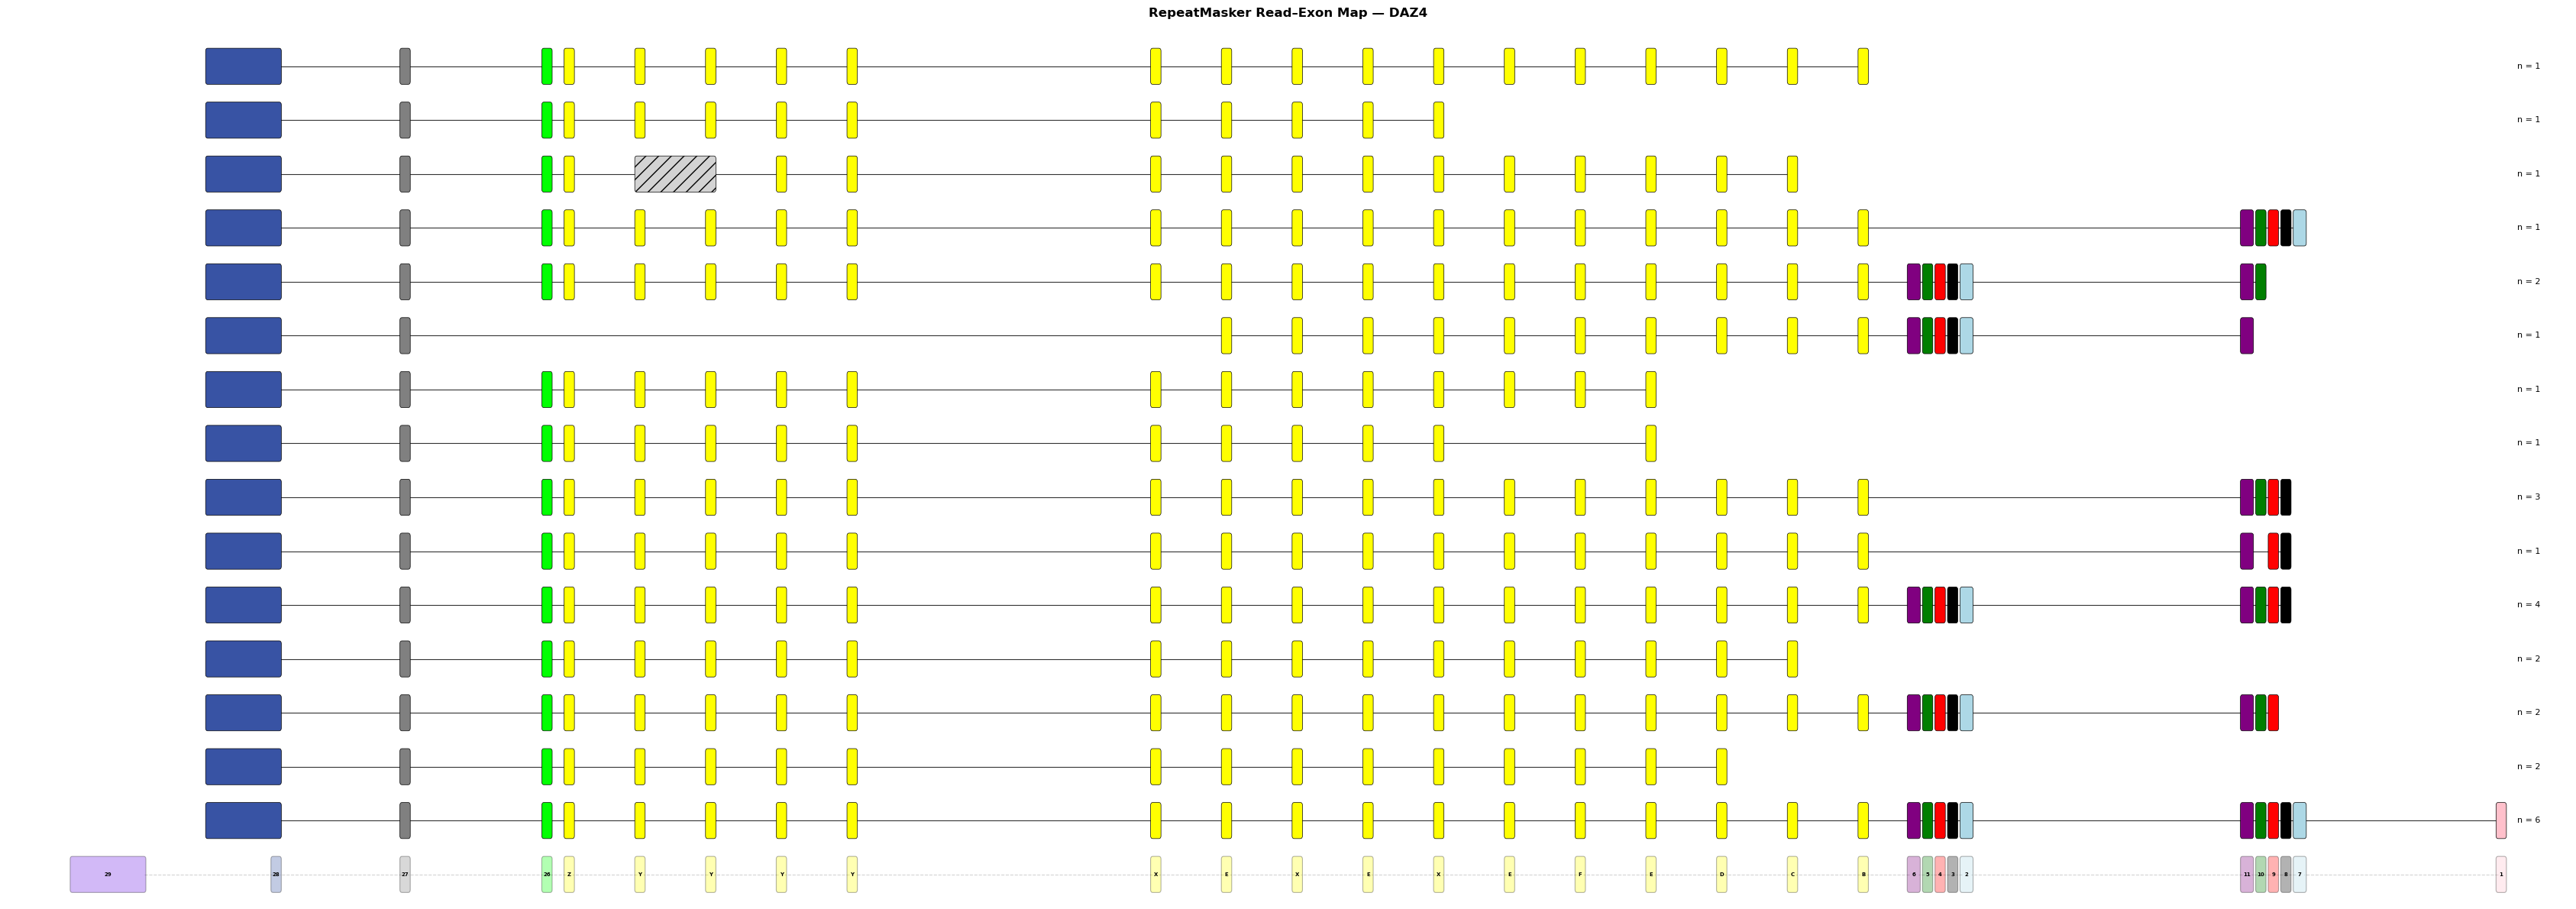

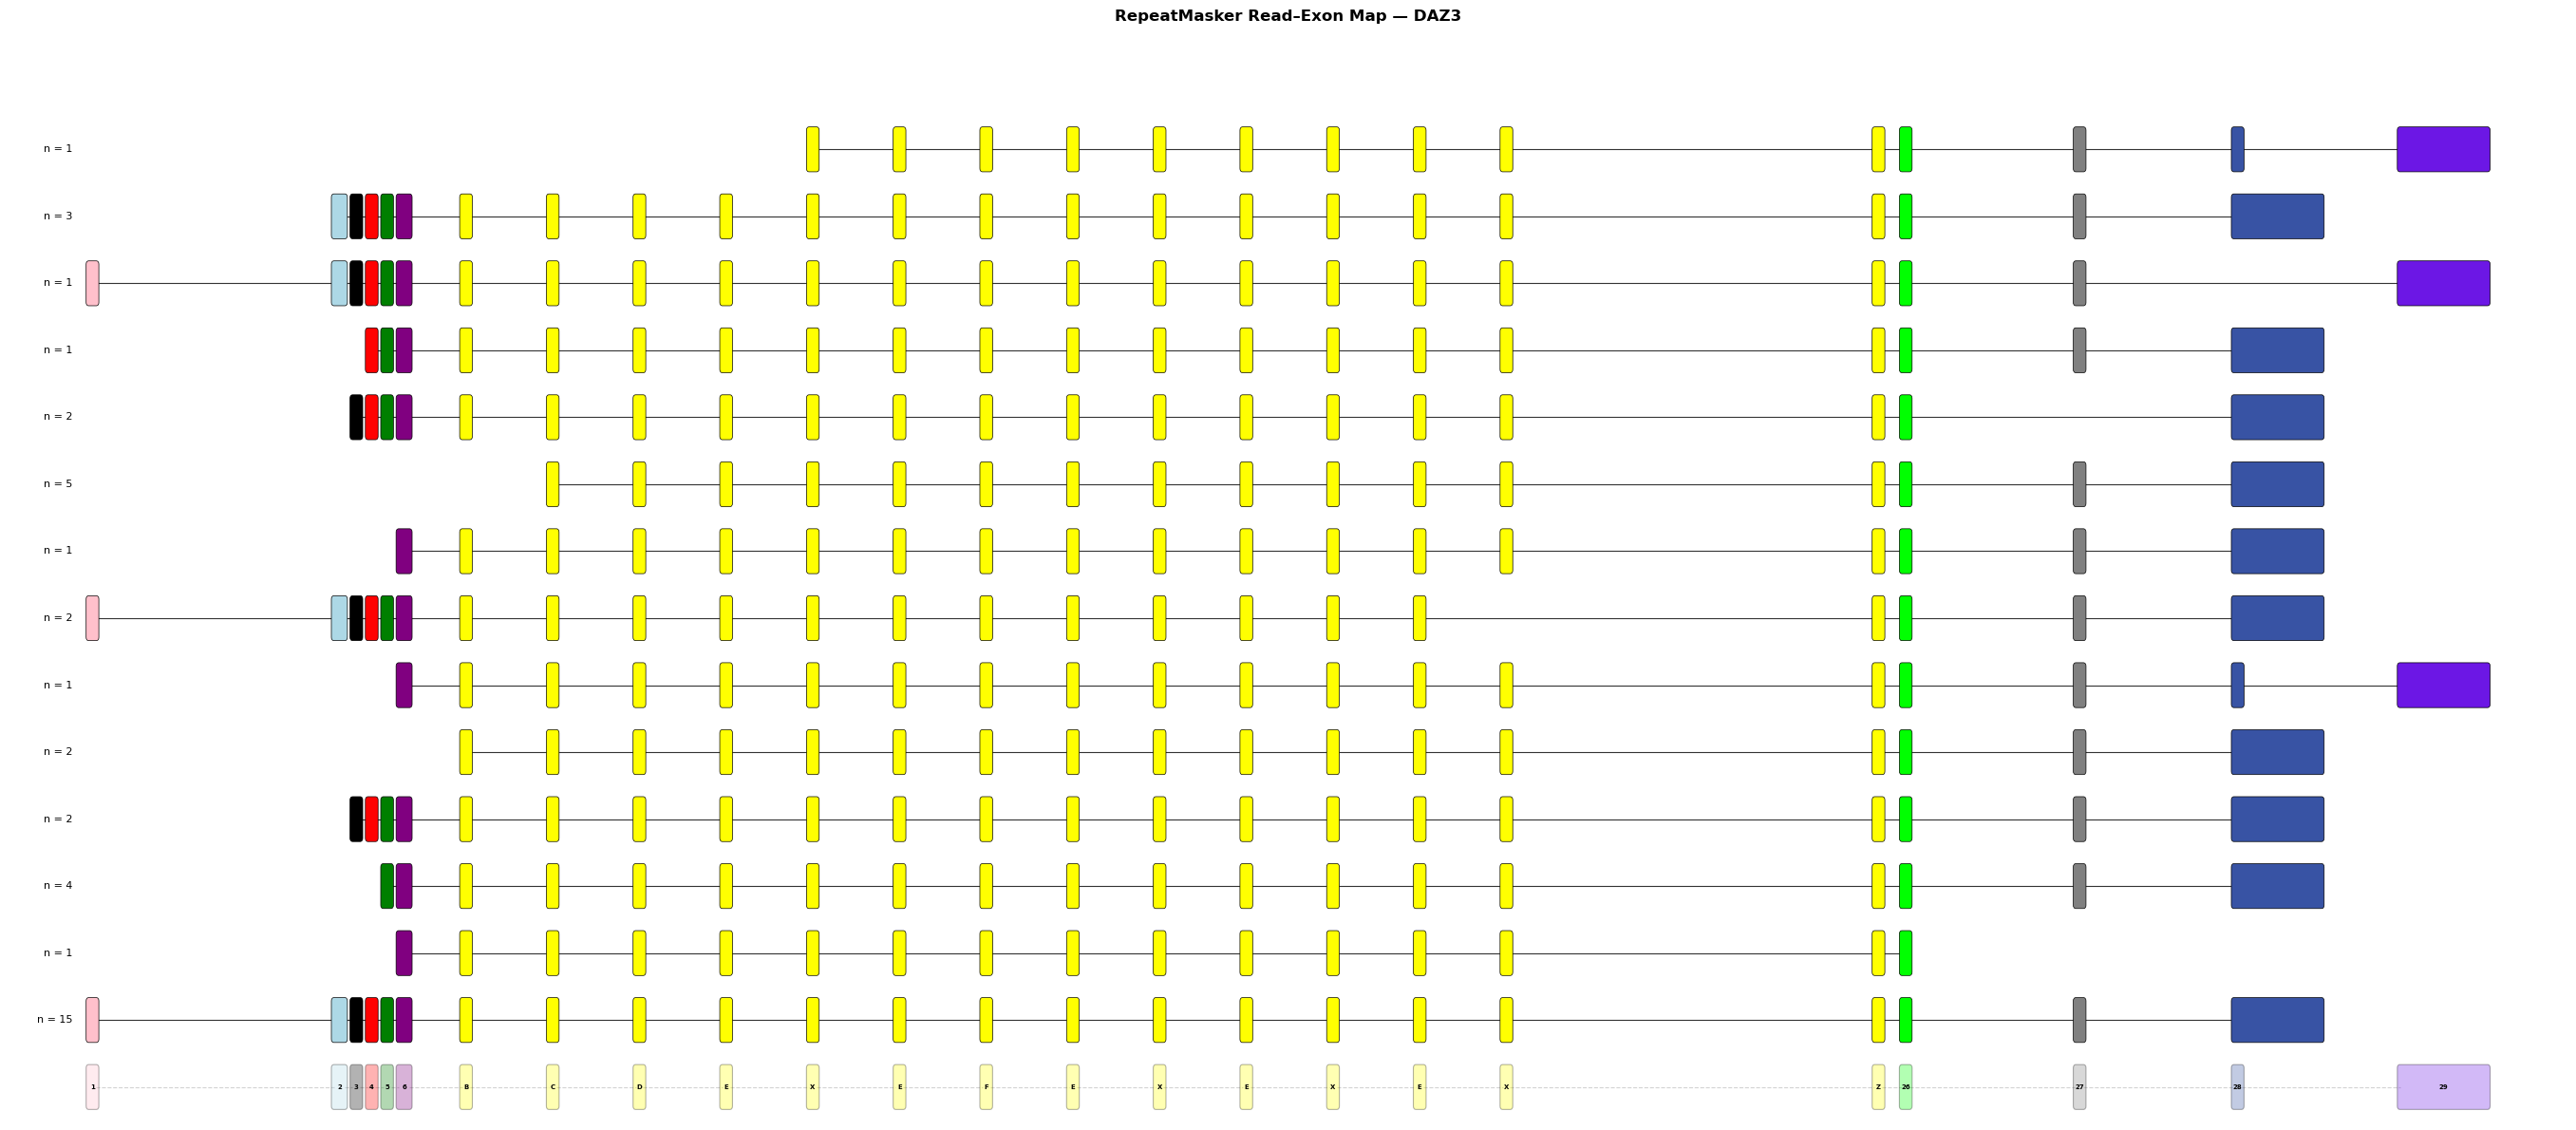

In [10]:
figures = plot_repeatmasker_reads_by_copy(gencodeRM)
for copy_name, (fig, ax) in figures.items():
    if fig is not None:
        fig.savefig(f'{copy_name}_reads_altTSS.png', dpi=300)
        fig.savefig(f'{copy_name}_reads_altTSS.pdf', dpi=300)

plt.show()

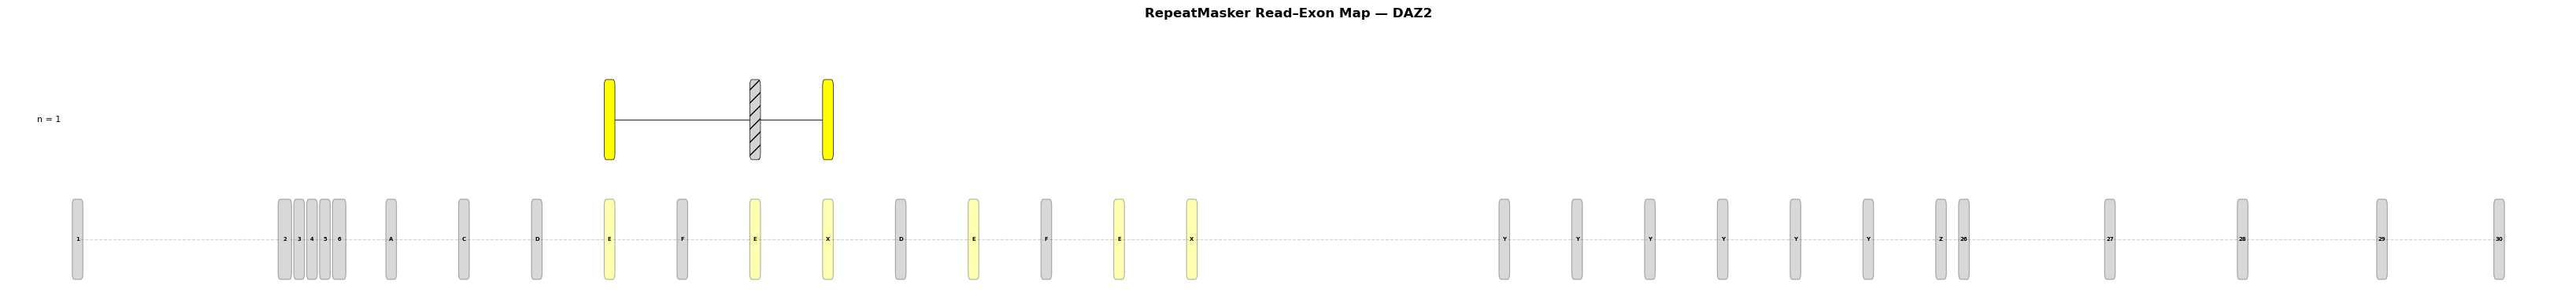

In [29]:
# Build the 3 segments manually
test_segs = [
    {
        'exons': ['E'],
        'fused': False,
        'width': get_exon_width('E'),
    },
    {
        'exons': ['E'],   # single exon so it matches one axis entry
        'fused': True,
        'width': get_exon_width('E'),
    },
    {
        'exons': ['X'],
        'fused': False,
        'width': get_exon_width('X'),
    },
]

test_structs = [{'segs': test_segs, 'count': 1}]

all_exons   = ['E', 'X']
exon_colors = {e: EXON_COLORS.get(e, '#808080') for e in all_exons}

fig, ax = plot_daz_copy('DAZ2', DAZ_COPIES['DAZ2'], test_structs,
                         all_exons, exon_colors, figsize_scale=1.0)

fig.savefig('test_daz2.pdf', dpi=600)
plt.show()


DAZ1

  Structure 1 (n=1): 1 - 2-7-12 - 3-8-13 - 4-9-14 - 5-10-15 - 6-11-16 - 3-8-13 - 4-9-14 - 5-10-15 - 6-11-16 - 2-7-12 - 3-8-13 - 4-9-14 - 5-10-15 - 6-11-16 - B - C - D - E - F - E - X - Y - Z - 26 - 27 - 28
    SRR31360662.10075556

  Structure 2 (n=6): 1 - 2-7-12 - 3-8-13 - 4-9-14 - 5-10-15 - 6-11-16 - 2-7-12 - 3-8-13 - 4-9-14 - 5-10-15 - 6-11-16 - 2-7-12 - 3-8-13 - 4-9-14 - 5-10-15 - 6-11-16 - B - C - D - E - F - E - X - Y - Z - 26 - 27 - 28
    SRR31360662.11636271
    SRR31360662.14576794
    SRR31360662.27014226
    SRR31360662.27528797
    SRR31360662.40964050
    SRR31360662.51882580

  Structure 3 (n=2): 1 - 2-7-12 - 3-8-13 - 4-9-14 - 5-10-15 - 6-11-16 - 2-7-12 - 3-8-13 - 4-9-14 - 5-10-15 - 6-11-16 - 2-7-12 - 3-8-13 - 4-9-14 - 5-10-15 - 6-11-16 - B - C - D - E - F - E - X - Y - Z - 26 - 27 - 28 - 29
    SRR31360662.14576804
    SRR31360662.6388860

  Structure 4 (n=2): 1 - 2-7-12 - 3-8-13 - 4-9-14 - 5-10-15 - 6-11-16 - 26
    SRR31360662.22729886
    SRR31360662.50730774


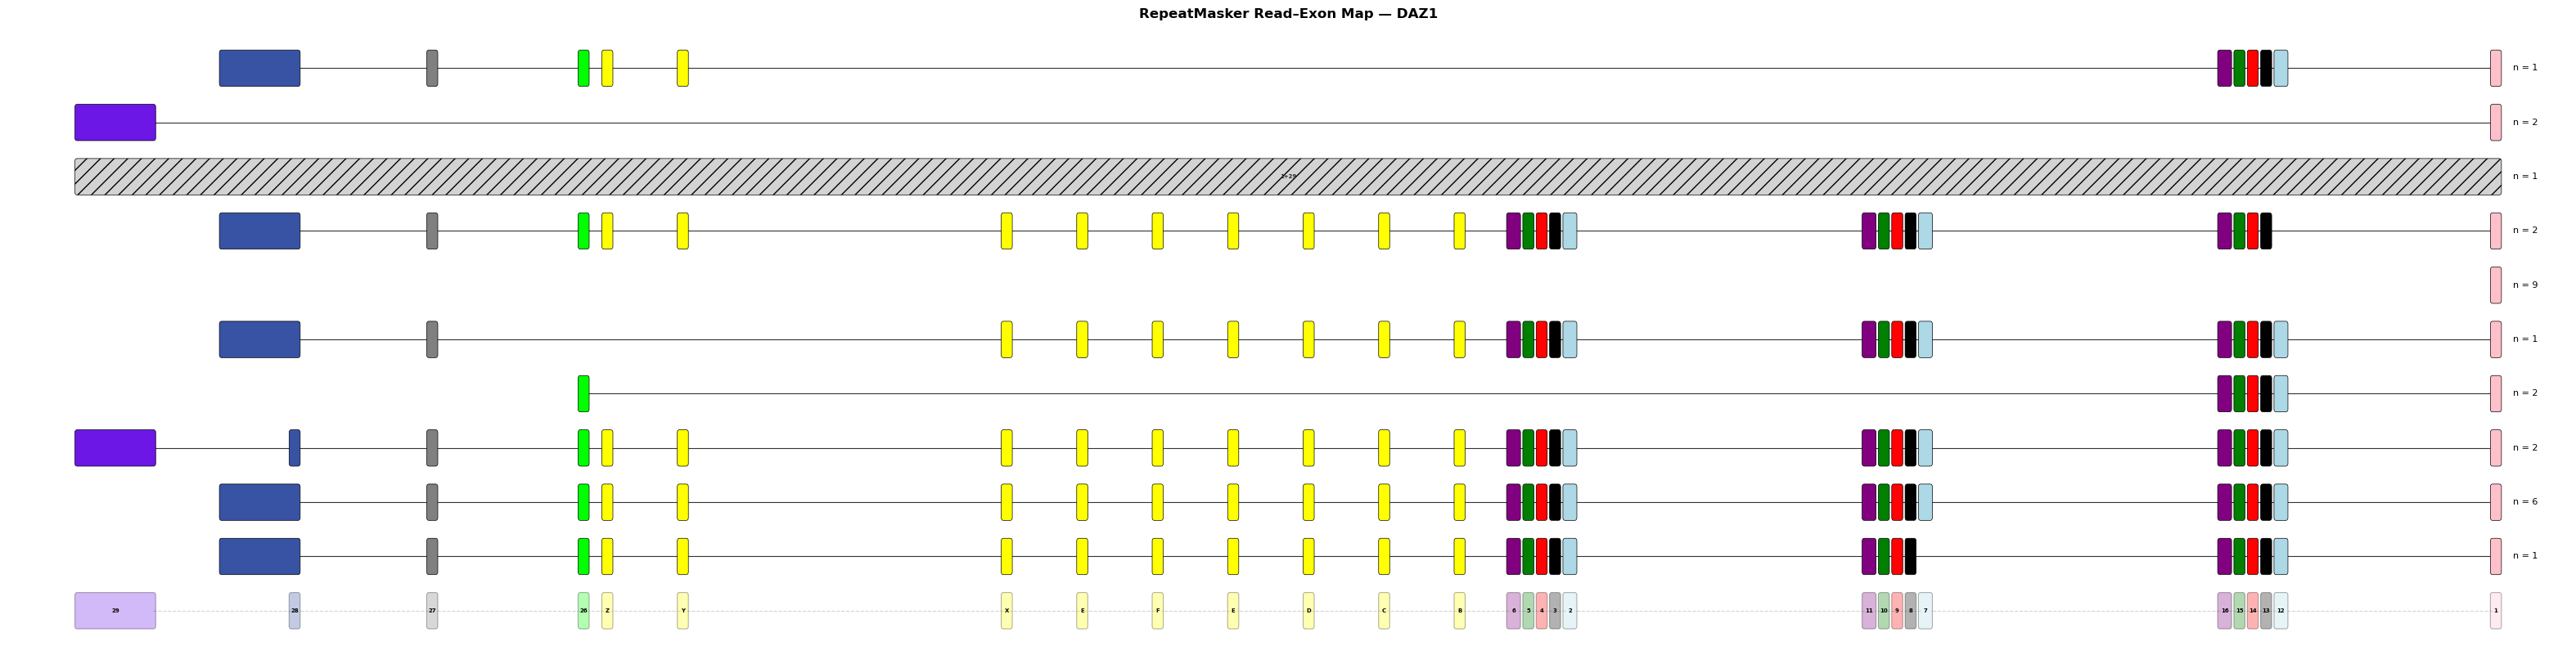

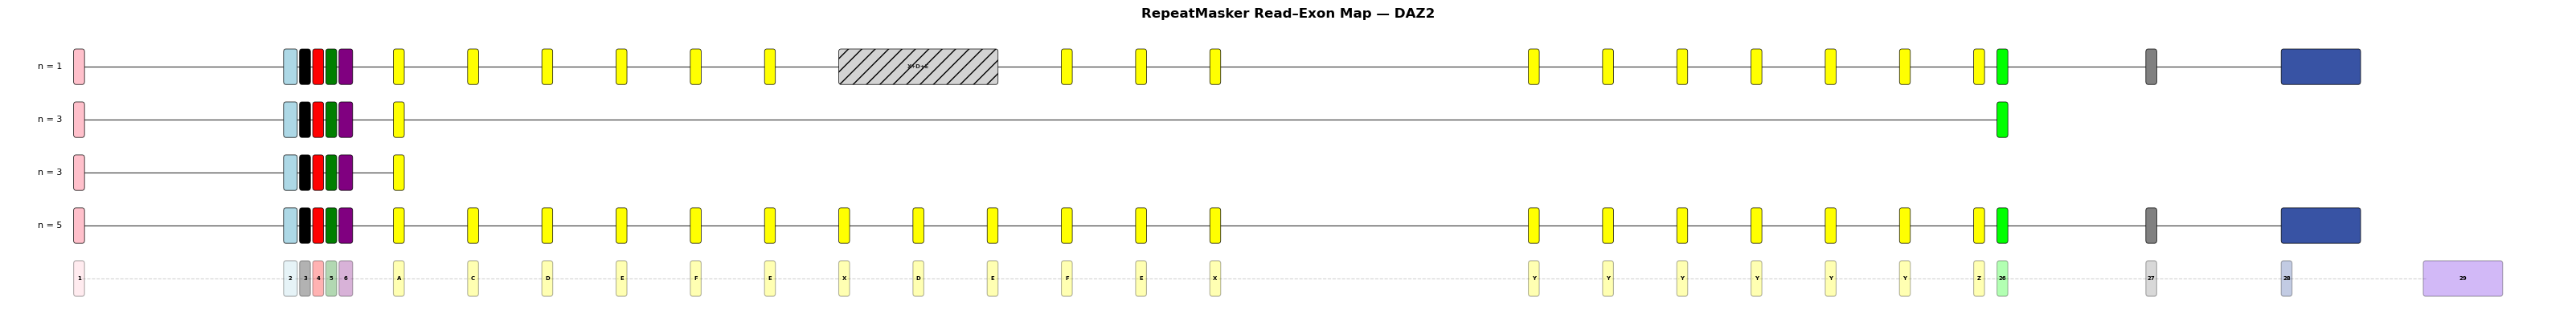

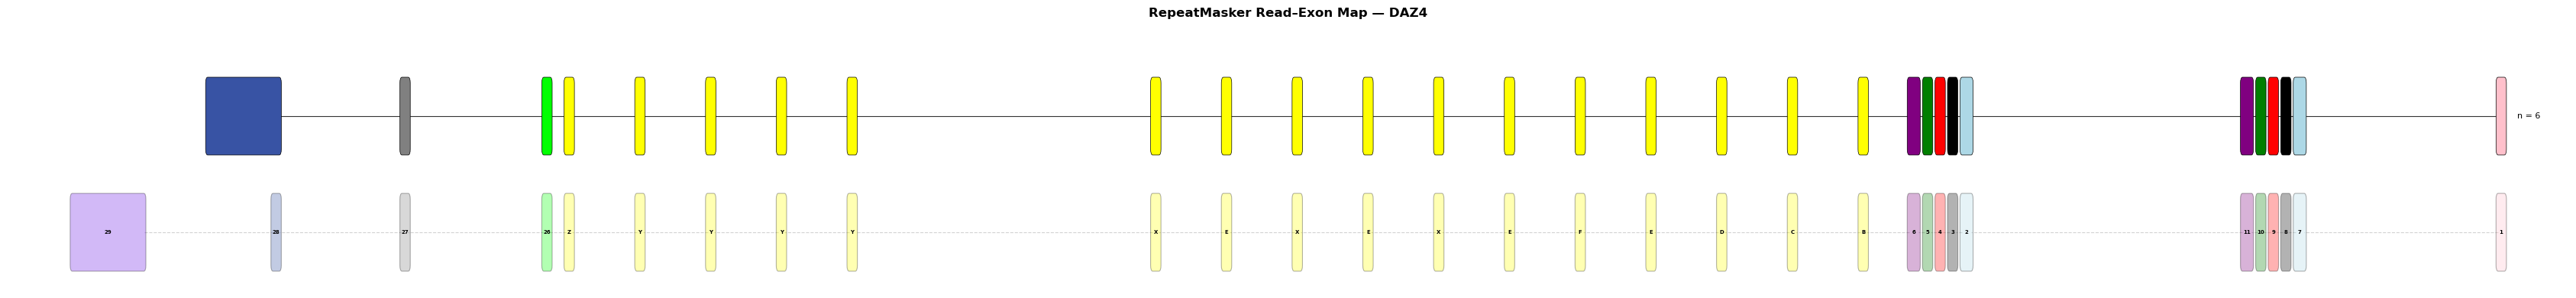

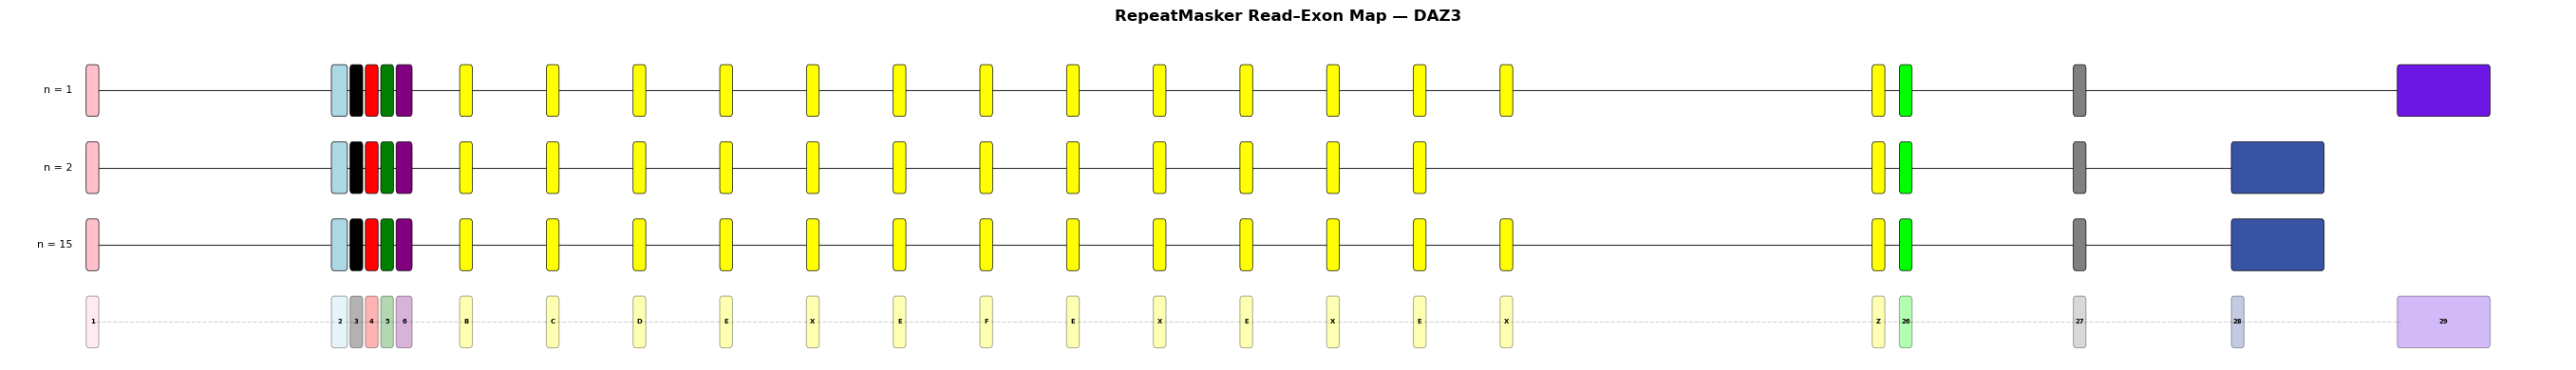

In [16]:
figures = plot_repeatmasker_reads_by_copy(gencodeRM)
for copy_name, (fig, ax) in figures.items():
    if fig is not None:
        fig.savefig(f'{copy_name}_reads.png', dpi=500)
        fig.savefig(f'{copy_name}_reads.pdf', dpi=300)

plt.show()

In [12]:
gencodeRM[gencodeRM[4]=="SRR31360662.6312857"]

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
4912,1878,0.0,0.0,0.0,SRR31360662.6312857,101,311,(3148),+,DAZ1_EXON1,Unspecified,1,211,(0),4913,None
4913,1382,0.0,0.0,0.0,SRR31360662.6312857,312,458,(3001),+,DAZ1_EXON2-7-12,Unspecified,1,147,(0),4914,None
4914,830,0.0,0.0,0.0,SRR31360662.6312857,472,563,(2896),+,DAZ1_EXON3-8-13,Unspecified,1,92,(0),4915,None
4915,461,0.0,0.0,0.0,SRR31360662.6312857,564,615,(2844),+,DAZ1_EXON4-9-14,Unspecified,1,52,(0),4916,None
4916,591,0.0,0.0,0.0,SRR31360662.6312857,616,679,(2780),+,DAZ1_EXON5-10-15,Unspecified,1,64,(0),4917,None
4917,1285,0.0,0.0,0.0,SRR31360662.6312857,680,819,(2640),+,DAZ1_EXON6-11-16,Unspecified,1,140,(0),4918,None
4918,655,1.4,0.0,0.0,SRR31360662.6312857,820,891,(2568),+,DAZ1_EXON17,Unspecified,1,72,(0),4919,None
4919,668,0.0,0.0,0.0,SRR31360662.6312857,892,963,(2496),+,DAZ1_EXON18,Unspecified,1,72,(0),4920,None
4920,665,0.0,0.0,0.0,SRR31360662.6312857,964,1035,(2424),+,DAZ1_EXON19,Unspecified,1,72,(0),4921,None
4921,657,0.0,0.0,0.0,SRR31360662.6312857,1036,1107,(2352),+,DAZ1_EXON20-22,Unspecified,1,72,(0),4922,None


In [6]:
def get_reads_with_intron_retention(df, exon_col=9, read_col=4,
                                    query_start_col=5, query_end_col=6,
                                    repeat_class_col=10, divergence_col=1):
    df = df.copy()

    raw_exon = df.iloc[:, exon_col].astype(str).str.split('EXON').str[-1].str.strip()

    df['exon_num'] = df.apply(
        lambda row: rename_exon_17(row.iloc[divergence_col], divergence_col)
            if raw_exon[row.name] == '17'
            else EXON_RENAME.get(raw_exon[row.name], raw_exon[row.name]),
        axis=1
    )

    is_simple = (
        df.iloc[:, repeat_class_col].astype(str).str.contains('Simple_repeat', case=False) |
        df.iloc[:, exon_col].astype(str).str.match(r'^\(.*\)n?$')
    )
    df = df[~is_simple].reset_index(drop=True)

    reads = list(dict.fromkeys(df.iloc[:, read_col]))
    retained_intron_reads = []

    for read in reads:
        sub    = df[df.iloc[:, read_col] == read]
        exons  = list(sub['exon_num'])
        r_ends = list(clean_coord(sub.iloc[:, query_end_col]))
        r_stts = list(clean_coord(sub.iloc[:, query_start_col]))

        if infer_orientation(exons):
            exons  = exons[::-1]
            r_ends = r_ends[::-1]
            r_stts = r_stts[::-1]

        segs = build_segments(exons, r_ends, r_stts)

        if any(seg['fused'] for seg in segs):
            retained_intron_reads.append(read)

    return retained_intron_reads

retained_reads = get_reads_with_intron_retention(gencodeRM)
print(f"Reads with intron retention: {len(retained_reads)}")
for read_id in retained_reads:
    print(read_id)

Reads with intron retention: 52
SRR31360662.11156260
SRR31360662.11452874
SRR31360662.13306692
SRR31360662.13403125
SRR31360662.13991365
SRR31360662.14700956
SRR31360662.15137394
SRR31360662.16246349
SRR31360662.17758383
SRR31360662.17986232
SRR31360662.19049641
SRR31360662.19113315
SRR31360662.19815469
SRR31360662.20019443
SRR31360662.20926389
SRR31360662.22521112
SRR31360662.22549473
SRR31360662.24988844
SRR31360662.25370657
SRR31360662.26147859
SRR31360662.26333164
SRR31360662.26933208
SRR31360662.29681999
SRR31360662.34732190
SRR31360662.35409276
SRR31360662.36913787
SRR31360662.39225979
SRR31360662.3956865
SRR31360662.40193707
SRR31360662.44496946
SRR31360662.44731708
SRR31360662.48283864
SRR31360662.49316795
SRR31360662.50334037
SRR31360662.5073665
SRR31360662.50892584
SRR31360662.51960663
SRR31360662.52850933
SRR31360662.53059403
SRR31360662.54574126
SRR31360662.56474035
SRR31360662.5719925
SRR31360662.58405249
SRR31360662.58526178
SRR31360662.59536542
SRR31360662.61309227
SRR31

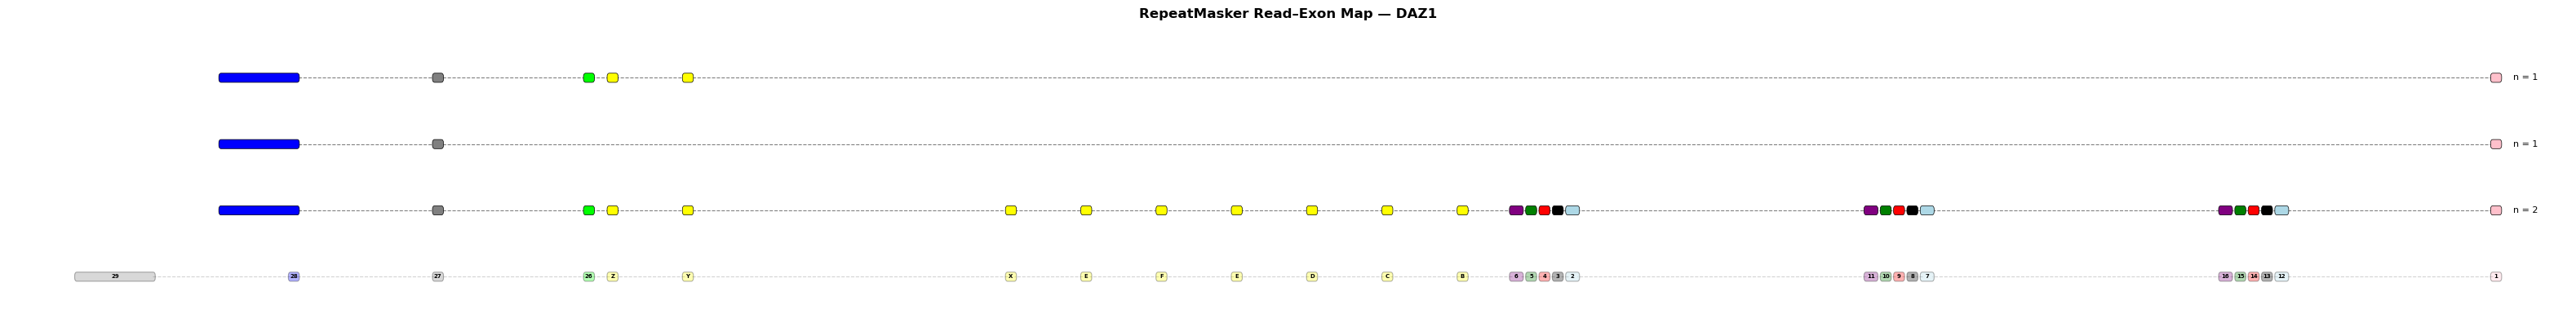

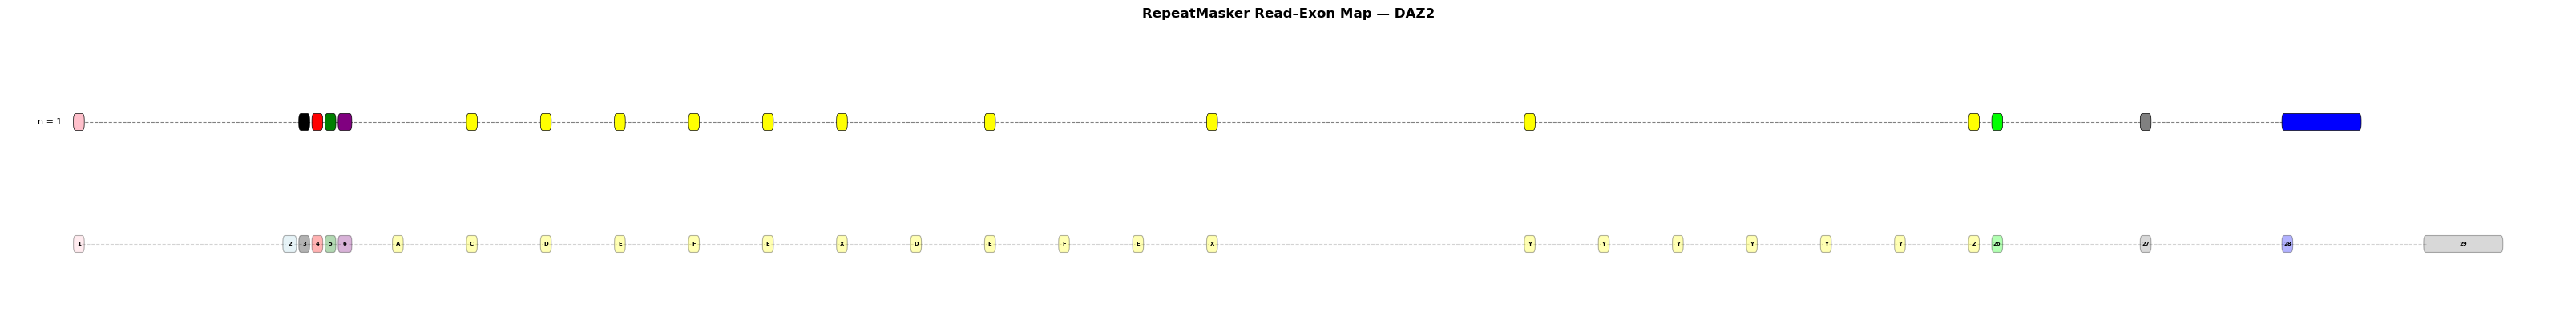

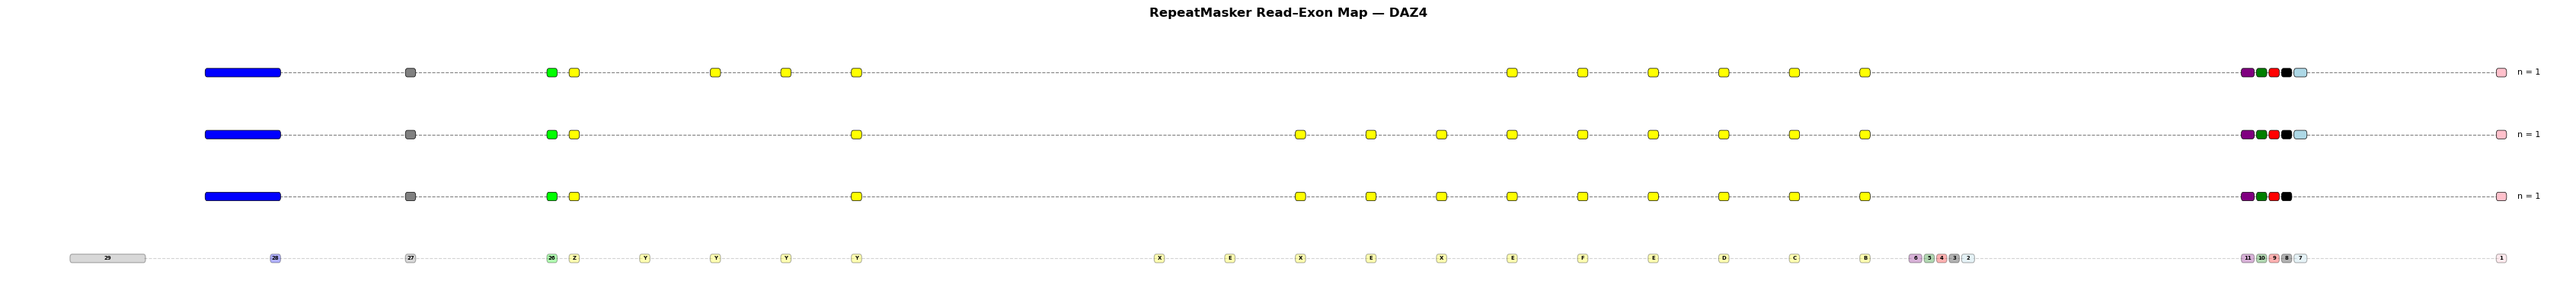

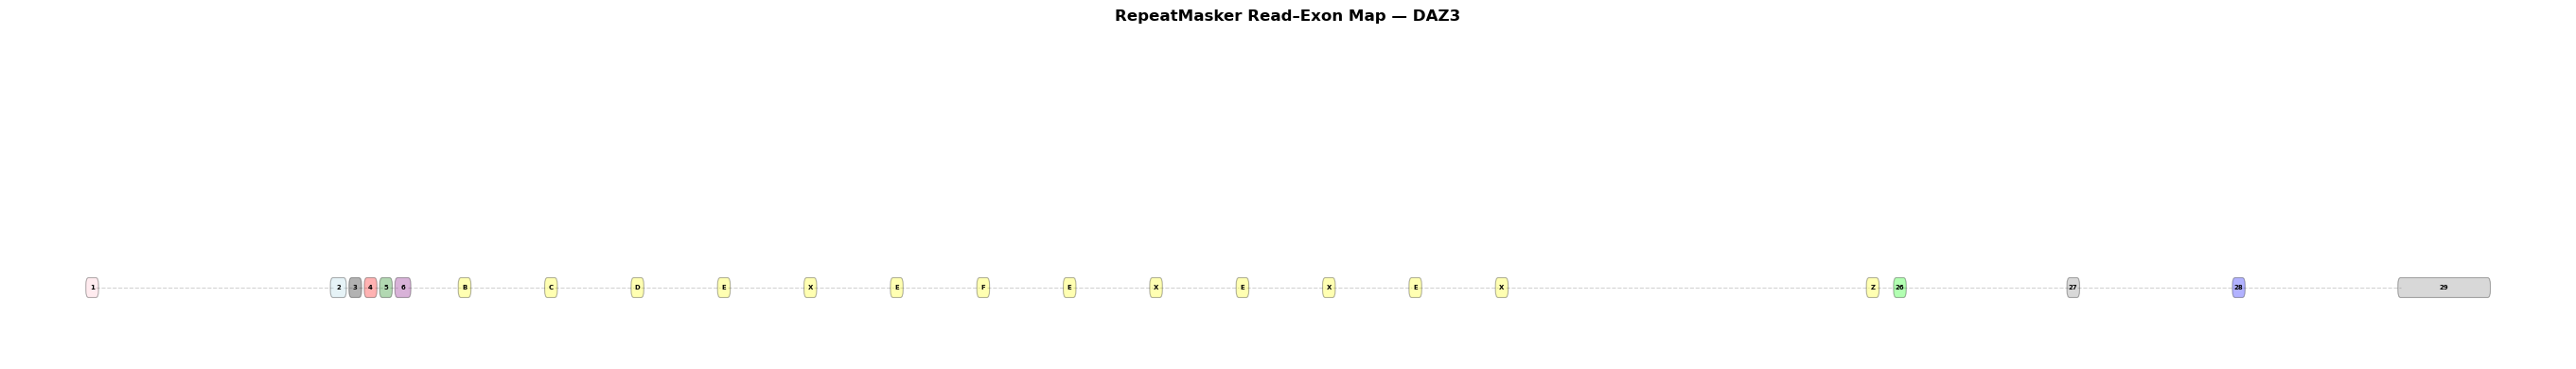

In [77]:
figures = plot_repeatmasker_reads_by_copy(pooledRM)
for copy_name, (fig, ax) in figures.items():
    if fig is not None:
        fig.savefig(f'{copy_name}_Pooledreads.png', dpi=300)
plt.show()

In [27]:
exonColors = {
    "1":"FFC0CB",
    "2-7-12": "ADD8E6",
    "3-8-13":"000000",
    "4-9-14":"FF0101",
    "5-10-15":"007F00",
    "6-11-16":"800080",
    "17":"FFFF01",
    '18': 'FFFF01', 
    '19': 'FFFF01', 
    '20-22': 'FFFF01',
    '21': 'FFFF01', 
    '23': 'FFFF01', 
    '24': 'FFFF01', 
    '25': 'FFFF01',
    '26': "01FF01",
    '27': '808080',
    '28': '0000FF',
    '29': '6C17E5'
    
}

In [48]:
test = gencodeRM[gencodeRM[4]=="SRR31360662.12434379"]
test

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
237,16867,0.0,0.0,0.0,SRR31360662.12434379,1,1857,(2272),C,DAZ1_EXON28,Unspecified,(0),1857,1,238,None
238,925,0.0,0.0,0.0,SRR31360662.12434379,1858,1956,(2173),C,DAZ1_EXON27,Unspecified,(0),99,1,239,None
239,309,0.0,0.0,0.0,SRR31360662.12434379,1957,1991,(2138),C,DAZ1_EXON26,Unspecified,(0),35,1,240,None
240,669,0.0,0.0,0.0,SRR31360662.12434379,1992,2063,(2066),C,DAZ1_EXON25,Unspecified,(0),72,1,241,None
241,665,0.0,0.0,0.0,SRR31360662.12434379,2064,2135,(1994),C,DAZ1_EXON24,Unspecified,(0),72,1,242,None
242,665,0.0,0.0,0.0,SRR31360662.12434379,2136,2207,(1922),C,DAZ1_EXON24,Unspecified,(0),72,1,243,None
243,665,0.0,0.0,0.0,SRR31360662.12434379,2208,2279,(1850),C,DAZ1_EXON24,Unspecified,(0),72,1,244,None
244,665,0.0,0.0,0.0,SRR31360662.12434379,2280,2351,(1778),C,DAZ1_EXON24,Unspecified,(0),72,1,245,None
245,665,0.0,0.0,0.0,SRR31360662.12434379,2352,2423,(1706),C,DAZ1_EXON24,Unspecified,(0),72,1,246,None
246,665,0.0,0.0,0.0,SRR31360662.12434379,2424,2495,(1634),C,DAZ1_EXON24,Unspecified,(0),72,1,247,None


In [42]:
fig, ax = plot_repeatmasker_reads(test)
plt.savefig('reads.png', dpi=300)
plt.show()

No reads found containing all required exons: 1


<Figure size 640x480 with 0 Axes>

In [32]:
gencodeRM[gencodeRM[4]=="SRR31360662.48736564"]

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
3655,4603,0.2,0.0,0.0,SRR31360662.48736564,1,492,(1868),C,DAZ1_EXON29,Unspecified,(1821),494,3,3656,None
3656,925,0.0,0.0,0.0,SRR31360662.48736564,491,589,(1771),C,DAZ1_EXON27,Unspecified,(0),99,1,3657,*
3657,309,0.0,0.0,0.0,SRR31360662.48736564,590,624,(1736),C,DAZ1_EXON26,Unspecified,(0),35,1,3658,None
3658,669,0.0,0.0,0.0,SRR31360662.48736564,625,696,(1664),C,DAZ1_EXON25,Unspecified,(0),72,1,3659,None
3659,668,0.0,0.0,0.0,SRR31360662.48736564,697,768,(1592),C,DAZ1_EXON23,Unspecified,(0),72,1,3660,None
3660,657,0.0,0.0,0.0,SRR31360662.48736564,769,840,(1520),C,DAZ1_EXON20-22,Unspecified,(0),72,1,3661,None
3661,668,0.0,0.0,0.0,SRR31360662.48736564,841,912,(1448),C,DAZ1_EXON23,Unspecified,(0),72,1,3662,None
3662,657,0.0,0.0,0.0,SRR31360662.48736564,913,984,(1376),C,DAZ1_EXON20-22,Unspecified,(0),72,1,3663,None
3663,668,0.0,0.0,0.0,SRR31360662.48736564,985,1056,(1304),C,DAZ1_EXON23,Unspecified,(0),72,1,3664,None
3664,657,0.0,0.0,0.0,SRR31360662.48736564,1057,1128,(1232),C,DAZ1_EXON20-22,Unspecified,(0),72,1,3665,None


In [12]:
pooledRM["Exon"] = pooledRM[9].astype(str).str.split("EXON").str[-1]

In [13]:
pooledRM

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,Exon
0,309,0.0,0.0,0.0,SRR12544672.130521,272,306,(1834),C,DAZ1_EXON26,Unspecified,(0),35,1,1,26
1,631,0.0,1.4,0.0,SRR12544672.130521,307,377,(1763),C,DAZ1_EXON25,Unspecified,(0),72,1,2,25
2,638,0.0,0.0,1.4,SRR12544672.130521,378,450,(1690),C,DAZ1_EXON23,Unspecified,(0),72,1,3,23
3,657,0.0,0.0,0.0,SRR12544672.130521,451,522,(1618),C,DAZ1_EXON20-22,Unspecified,(0),72,1,4,20-22
4,668,0.0,0.0,0.0,SRR12544672.130521,523,594,(1546),C,DAZ1_EXON23,Unspecified,(0),72,1,5,23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
348,591,0.0,0.0,0.0,SRR12544673.93059,3134,3197,(503),C,DAZ1_EXON5-10-15,Unspecified,(0),64,1,349,5-10-15
349,461,0.0,0.0,0.0,SRR12544673.93059,3198,3249,(451),C,DAZ1_EXON4-9-14,Unspecified,(0),52,1,350,4-9-14
350,830,0.0,0.0,0.0,SRR12544673.93059,3250,3341,(359),C,DAZ1_EXON3-8-13,Unspecified,(0),92,1,351,3-8-13
351,1382,0.0,0.0,0.0,SRR12544673.93059,3342,3488,(212),C,DAZ1_EXON2-7-12,Unspecified,(0),147,1,352,2-7-12


In [17]:
annotation = pd.read_csv("/project/mkonkel/tangeno/users/giannim/chrY/CombinedFiles/HG01358_combinedAnnotation.04092026.csv")
annotation

,Unnamed: 0,sample,contig,start_merged,end_merged,strand,gene_name,biotype,Liftoff,PangenomeGraph,RM_Amplicon_Caller,COORDINATES_DIFFER,Liftoff_Coordinates,PangenomeGraph_Coordinates,RM_Amplicon_Coordinates,seqclass,RM_Amplicon_gene,RM_Amplicon_Exons,RM_Amplicon_DAZrepeat_Pattern,RM_Amplicon_geneCompleteness
0,0,HG01358,HG01358_chrY,83580,84928,+,ENSG00000292329,pseudogene,NOT_CALLED,CALLED,NOT_CALLED,.,.,HG01358_chrY:83580-84928(+),.,PAR1,.,.,.,.
1,1,HG01358,HG01358_chrY,97519,104985,-,ENSG00000310553,lncRNA,NOT_CALLED,CALLED,NOT_CALLED,.,.,HG01358_chrY:97519-104985(-),.,PAR1,.,.,.,.
2,2,HG01358,HG01358_chrY,104099,105770,-,LOC124905300,protein_coding,CALLED,NOT_CALLED,NOT_CALLED,.,HG01358_chrY:104099-105770(-),.,.,PAR1,.,.,.,.
3,3,HG01358,HG01358_chrY,105095,132117,+,PLCXD1,protein_coding,CALLED,CALLED,NOT_CALLED,YES,HG01358_chrY:105129-132117(+),HG01358_chrY:105095-132117(+),.,PAR1,.,.,.,.
4,4,HG01358,HG01358_chrY,107438,111149,-,ENSG00000310554,lncRNA,NOT_CALLED,CALLED,NOT_CALLED,.,.,HG01358_chrY:107438-111149(-),.,PAR1,.,.,.,.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
875,875,HG01358,HG01358_chrY_random0000621,196935,199071,+,CDY8P,pseudogene,CALLED,CALLED,NOT_CALLED,YES,HG01358_chrY_random0000621:196935-199071(+),HG01358_chrY_random0000621:197361-198970(+),.,PAR1,.,.,.,.
876,876,HG01358,HG01358_chrY_random0000621,200849,203659,+,CDY2A,protein_coding,CALLED,CALLED,CALLED,NO,HG01358_chrY_random0000621:200849-202808(+),HG01358_chrY_random0000621:200849-202808(+),HG01358_chrY_random0000621:200851-203659(+),PAR1,CDY2,"[['17250', '0.8', '0.0', '0.2', 'HG01358_chrY_...",.,Full_Exon_Copy
877,877,HG01358,HG01358_chrY_random0000621,243543,243870,+,ELOCP12|ELOCP6,pseudogene,CALLED,CALLED,NOT_CALLED,NO,HG01358_chrY_random0000621:243543-243870(+),HG01358_chrY_random0000621:243543-243870(+),.,PAR1,.,.,.,.
878,878,HG01358,HG01358_chrY,6069326,6069601,.,PRY2,protein_coding,NOT_CALLED,NOT_CALLED,CALLED,False,.,.,HG01358_chrY:6069326-6069601,.,PRY2,"[['768', '2.3', '0.0', '0.0', 'HG01358_chrY', ...",.,Truncated_Copy


In [20]:
annotation[annotation["RM_Amplicon_gene"]=="DAZ1"].iloc[0]["RM_Amplicon_Exons"]

"[['16504', '0.0', '0.0', '0.0', 'HG01358_chrY', 23679778, 23681634, '(28710687)', 'C', 'DAZ1_EXON28', 'Unspecified', '(0)', '1857', '1', '13746', 'HG01358', 'V2_Assembly', 'DAZ1_Copy_1', 'Full_Exon_Copy', 'DAZ1', 0.19333333333333333], ['906', '0.0', '0.0', '0.0', 'HG01358_chrY', 23685598, 23685696, '(28706625)', 'C', 'DAZ1_EXON27', 'Unspecified', '(0)', '99', '1', '13752', 'HG01358', 'V2_Assembly', 'DAZ1_Copy_1', 'Full_Exon_Copy', 'DAZ1', 0.19333333333333333], ['302', '0.0', '0.0', '0.0', 'HG01358_chrY', 23690270, 23690304, '(28702017)', 'C', 'DAZ1_EXON26', 'Unspecified', '(0)', '35', '1', '13754', 'HG01358', 'V2_Assembly', 'DAZ1_Copy_1', 'Full_Exon_Copy', 'DAZ1', 0.19333333333333333], ['655', '0.0', '0.0', '0.0', 'HG01358_chrY', 23691049, 23691120, '(28701201)', 'C', 'EXON_Z', 'Unspecified', '(0)', '72', '1', '13755', 'HG01358', 'V2_Assembly', 'DAZ1_Copy_1', 'Full_Exon_Copy', 'DAZ1', 0.19333333333333333], ['651', '0.0', '0.0', '0.0', 'HG01358_chrY', 23693434, 23693505, '(28698816)', 